# MeatLens — Thesis Training Notebook

This notebook trains and compares four ImageNet-pretrained CNN backbones on the MeatLens ROI-only dataset across Experiment 1 and Experiment 2.

- Backbones: MobileNetV3Small, EfficientNetB0, ResNet50, and MobileNetV2.
- Two-phase transfer learning: frozen feature extraction, then percentage-based fine-tuning of the top backbone layers.
- Mild augmentation is applied only to the training set.
- Validation and test sets are kept clean with no augmentation.
- The `time` column is used only for diagnostics and plots, not as a CNN input feature.
- Final comparison is based primarily on macro F1-score on unseen test images.
- Cross-experiment results may differ because the two experiments can reflect distribution shift.


In [38]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, MobileNetV3Small, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_effnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mnv2
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as preprocess_mnv3
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS_HEAD = 8
EPOCHS_FINE = 20
LR_HEAD = 1e-3
LR_FINE = 1e-5

SPLITS = {
    "exp1": {"train": "exp1_train.csv", "val": "exp1_val.csv", "test": "exp1_test.csv"},
    "exp2": {"train": "exp2_train.csv", "val": "exp2_val.csv", "test": "exp2_test.csv"},
}

LABEL_ORDER = ["fresh", "not fresh", "spoiled"]
EXPECTED_TOTAL_COUNTS = {"fresh": 156, "not fresh": 191, "spoiled": 181}

BACKBONES = ["MobileNetV3Small", "EfficientNetB0", "ResNet50", "MobileNetV2"]
BACKBONE_SPECS = {
    "MobileNetV3Small": {
        "factory": MobileNetV3Small,
        "preprocess_fn": preprocess_mnv3,
        "short_name": "mobilenetv3",
        "fine_tune_fraction": 0.25,
        "fine_tune_lr": 1e-5,
    },
    "EfficientNetB0": {
        "factory": EfficientNetB0,
        "preprocess_fn": preprocess_effnet,
        "short_name": "efficientnetb0",
        "fine_tune_fraction": 0.20,
        "fine_tune_lr": 1e-5,
    },
    "ResNet50": {
        "factory": ResNet50,
        "preprocess_fn": preprocess_resnet,
        "short_name": "resnet50",
        "fine_tune_fraction": 0.15,
        "fine_tune_lr": 5e-6,
    },
    "MobileNetV2": {
        "factory": MobileNetV2,
        "preprocess_fn": preprocess_mnv2,
        "short_name": "mobilenetv2",
        "fine_tune_fraction": 0.20,
        "fine_tune_lr": 1e-5,
    },
}

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

try:
    tf.keras.utils.set_random_seed(SEED)
except Exception:
    tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [40]:
def _resolve_folder_name(sample_dir: Path, folder: str) -> str:
    folder_key = str(folder).strip().lower()
    if not sample_dir.exists():
        return str(folder).strip()
    for candidate in sample_dir.iterdir():
        if candidate.is_dir() and candidate.name.strip().lower() == folder_key:
            return candidate.name
    return str(folder).strip()


def resolve_roi_path(sample_number, folder, roi_file):
    sample_dir = Path(f"Pork Shoulder - sample {int(sample_number)}")
    folder_name = _resolve_folder_name(sample_dir, folder)
    roi_path = Path(str(roi_file))
    alt_name = roi_path.name
    if "_roi" in roi_path.stem:
        alt_name = roi_path.stem.replace("_roi", "") + roi_path.suffix
    candidates = [
        sample_dir / folder_name / roi_path.name,
        sample_dir / folder_name / alt_name,
        Path("processed_images") / sample_dir / folder_name / roi_path.name,
        Path("processed_images") / sample_dir / folder_name / alt_name,
        sample_dir / roi_path.name,
        sample_dir / alt_name,
        Path("processed_images") / sample_dir / roi_path.name,
        Path("processed_images") / sample_dir / alt_name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(candidates[0])


def load_split(csv_path):
    df = pd.read_csv(csv_path)
    df = df.copy()
    df["roi_path"] = df.apply(
        lambda row: resolve_roi_path(row["sample_number"], row["folder"], row["roi_file"]),
        axis=1,
    )
    return df


def filter_existing_roi_rows(df, split_name=""):
    exists_mask = df["roi_path"].map(lambda p: Path(p).exists())
    missing_df = df.loc[~exists_mask].copy().reset_index(drop=True)
    clean_df = df.loc[exists_mask].copy().reset_index(drop=True)
    if len(missing_df) > 0:
        print(f"{split_name}: missing ROI files = {len(missing_df)}")
        display(missing_df[["roi_file", "sample_number", "folder", "roi_path"]].head())
    return clean_df, missing_df


def class_distribution_table(df):
    counts = df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0).rename("count")
    return counts.reset_index().rename(columns={"index": "label"})


def sample_number_table(df):
    return (
        df.groupby("sample_number")
        .size()
        .rename("image_count")
        .reset_index()
        .sort_values(["image_count", "sample_number"], ascending=[False, True])
        .reset_index(drop=True)
    )


def parse_time_to_hours(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() > 0:
        return numeric
    parsed = pd.to_timedelta(series.astype(str), errors="coerce")
    if parsed.notna().sum() > 0:
        return parsed.dt.total_seconds() / 3600.0
    extracted = series.astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0]
    return pd.to_numeric(extracted, errors="coerce")


def plot_time_distribution(df, title):
    if "time" not in df.columns or df["time"].isna().all():
        return
    tmp = df.copy()
    tmp["time_hours"] = parse_time_to_hours(tmp["time"])
    tmp = tmp.dropna(subset=["time_hours"])
    if tmp.empty:
        print(f"{title}: time column could not be parsed for plotting.")
        return
    plt.figure(figsize=(10, 4))
    sns.histplot(data=tmp, x="time_hours", hue="label", bins=18, multiple="stack")
    plt.title(f"{title} - Time distribution by class (analysis only)")
    plt.xlabel("Time (hours or numeric equivalent)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


raw_frames = []
for exp_name, split_paths in SPLITS.items():
    for split_name, csv_path in split_paths.items():
        df_split = load_split(csv_path)
        df_split["experiment"] = exp_name
        df_split["split"] = split_name
        raw_frames.append(df_split)

all_df = pd.concat(raw_frames, ignore_index=True)
unique_df = all_df.drop_duplicates(subset=["roi_path"]).copy().reset_index(drop=True)
label_vocab = [label for label in LABEL_ORDER if label in unique_df["label"].astype(str).unique()]
if len(label_vocab) != len(LABEL_ORDER):
    label_vocab = sorted(unique_df["label"].astype(str).unique().tolist())
label_lookup = layers.StringLookup(vocabulary=label_vocab, num_oov_indices=0)
label_to_index = {label: int(label_lookup(tf.constant(label)).numpy()) for label in label_vocab}
index_to_label = {index: label for label, index in label_to_index.items()}

actual_counts = unique_df["label"].value_counts().reindex(label_vocab, fill_value=0).rename("actual_count")
expected_counts = pd.Series(EXPECTED_TOTAL_COUNTS).reindex(label_vocab).rename("expected_count")
count_check_df = pd.concat([expected_counts, actual_counts], axis=1).reset_index().rename(columns={"index": "label"})
print("Global label count check (unique ROI rows):")
display(count_check_df)

print("Class distribution across unique ROI rows:")
display(class_distribution_table(unique_df))

print("Images per sample_number across unique ROI rows:")
display(sample_number_table(unique_df))

print("Repeated across both experiment files (for reference only):")
display(class_distribution_table(all_df))


def compute_class_weights_from_df(train_df):
    counts = train_df["label"].value_counts().reindex(label_vocab, fill_value=0)
    total = float(counts.sum())
    weights = {}
    for label in label_vocab:
        count = float(counts[label])
        if count == 0:
            weights[label_to_index[label]] = 0.0
        else:
            weights[label_to_index[label]] = total / (len(label_vocab) * count)
    return weights


def show_split_diagnostics(df, title):
    print(f"\n{title} - class distribution")
    display(class_distribution_table(df))
    print(f"{title} - images per sample_number")
    display(sample_number_table(df))
    plot_time_distribution(df, title)

Global label count check (unique ROI rows):


,label,expected_count,actual_count
0,fresh,156,156
1,not fresh,191,191
2,spoiled,181,181


Class distribution across unique ROI rows:


,label,count
0,fresh,156
1,not fresh,191
2,spoiled,181


Images per sample_number across unique ROI rows:


,sample_number,image_count
0,2,276
1,1,252


Repeated across both experiment files (for reference only):


,label,count
0,fresh,312
1,not fresh,382
2,spoiled,362


In [41]:
def _depthwise_filter(img, kernel_2d):
    kernel = tf.constant(kernel_2d, dtype=tf.float32)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]
    kernel = tf.repeat(kernel, repeats=3, axis=2)
    img_4d = tf.expand_dims(img, axis=0)
    filtered = tf.nn.depthwise_conv2d(img_4d, kernel, strides=[1, 1, 1, 1], padding="SAME")
    return tf.squeeze(filtered, axis=0)


def augment_training_image(img):
    def brighten(x):
        delta = tf.random.uniform([], -0.06, 0.06)
        return tf.image.adjust_brightness(x, delta)

    def adjust_contrast(x):
        factor = tf.random.uniform([], 0.90, 1.10)
        return tf.image.adjust_contrast(x, factor)

    def add_noise(x):
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.015)
        return x + noise

    def blur_or_sharpen(x):
        blur_kernel = [[1.0 / 9.0] * 3, [1.0 / 9.0] * 3, [1.0 / 9.0] * 3]
        sharpen_kernel = [[0.0, -1.0, 0.0], [-1.0, 5.0, -1.0], [0.0, -1.0, 0.0]]
        choice = tf.random.uniform([])
        blurred = _depthwise_filter(x, blur_kernel)
        sharpened = _depthwise_filter(x, sharpen_kernel)
        return tf.cond(choice < 0.5, lambda: 0.85 * x + 0.15 * blurred, lambda: 0.85 * x + 0.15 * sharpened)

    img = tf.cond(tf.random.uniform([]) < 0.5, lambda: tf.image.flip_left_right(img), lambda: img)
    img = brighten(img)
    img = adjust_contrast(img)
    img = tf.cond(tf.random.uniform([]) < 0.6, lambda: add_noise(img), lambda: img)
    img = tf.cond(tf.random.uniform([]) < 0.5, lambda: blur_or_sharpen(img), lambda: img)
    return tf.clip_by_value(img, 0.0, 1.0)


def load_and_preprocess_image(path, label, training=False, preprocess_fn=None):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.image.convert_image_dtype(img, tf.float32)
    if training:
        img = augment_training_image(img)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = img * 255.0
    if preprocess_fn is None:
        preprocess_fn = preprocess_mnv3
    img = preprocess_fn(img)
    return img, label


def make_dataset(df, preprocess_fn, training=False):
    paths = df["roi_path"].astype(str).values
    labels = label_lookup(tf.constant(df["label"].astype(str).values))
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, l: load_and_preprocess_image(p, l, training=training, preprocess_fn=preprocess_fn), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


def build_model(backbone_name):
    spec = BACKBONE_SPECS[backbone_name]
    backbone = spec["factory"](input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
    backbone.trainable = False

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(label_vocab), activation="softmax")(x)
    model = models.Model(inputs, outputs, name=f"meatlens_{spec['short_name']}")
    return model, backbone, spec["preprocess_fn"]


class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        self.y_true = np.concatenate([y.numpy() for _, y in validation_data], axis=0)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probs = self.model.predict(self.validation_data, verbose=0)
        preds = probs.argmax(axis=1)
        logs["val_f1_macro"] = f1_score(self.y_true, preds, average="macro", zero_division=0)


def make_callbacks(run_name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{run_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
        ),
    ]


def compute_fine_tuning_cutoff(backbone, fraction):
    trainable_layers = [layer for layer in backbone.layers if not isinstance(layer, layers.InputLayer)]
    cutoff_index = max(0, int(len(trainable_layers) * (1.0 - fraction)))
    return trainable_layers, cutoff_index


def apply_fine_tuning(backbone, fraction):
    backbone.trainable = True
    trainable_layers, cutoff_index = compute_fine_tuning_cutoff(backbone, fraction)
    for i, layer in enumerate(trainable_layers):
        if i < cutoff_index or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True
    return backbone


def train_two_phase(model, backbone, train_ds, val_ds, backbone_name, run_name, class_weight):
    spec = BACKBONE_SPECS[backbone_name]
    val_f1_callback = MacroF1Callback(val_ds)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_HEAD),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    head_callbacks = make_callbacks(f"{run_name}_phase1") + [val_f1_callback]
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        class_weight=class_weight,
        callbacks=head_callbacks,
        verbose=1,
    )

    apply_fine_tuning(backbone, spec["fine_tune_fraction"])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(spec["fine_tune_lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    fine_callbacks = make_callbacks(f"{run_name}_phase2") + [MacroF1Callback(val_ds)]
    head_epochs_run = max(1, len(history_head.epoch))
    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=head_epochs_run,
        epochs=head_epochs_run + EPOCHS_FINE,
        class_weight=class_weight,
        callbacks=fine_callbacks,
        verbose=1,
    )
    return history_head, history_fine


def combine_histories(history_head, history_fine):
    combined = {}
    all_keys = set(history_head.history.keys()) | set(history_fine.history.keys())
    for key in all_keys:
        combined[key] = history_head.history.get(key, []) + history_fine.history.get(key, [])
    return combined


def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history.get("loss", []), label="train")
    axes[0].plot(history.get("val_loss", []), label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.get("accuracy", []), label="train")
    axes[1].plot(history.get("val_accuracy", []), label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history.get("val_f1_macro", []), label="val macro F1")
    axes[2].set_title(f"{title} - Validation Macro F1")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_heatmaps(cm, cm_norm, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_vocab, yticklabels=label_vocab, ax=axes[0])
    axes[0].set_title(f"{title} - Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=label_vocab, yticklabels=label_vocab, ax=axes[1], vmin=0.0, vmax=1.0)
    axes[1].set_title(f"{title} - Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_ds, test_df, title):
    y_true = label_lookup(tf.constant(test_df["label"].astype(str).values)).numpy()
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    report_text = classification_report(y_true, y_pred, target_names=label_vocab, zero_division=0)
    report_df = pd.DataFrame(
        classification_report(y_true, y_pred, target_names=label_vocab, zero_division=0, output_dict=True)
    ).transpose()
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(label_vocab)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    print(f"\n{title} classification report:\n{report_text}")
    display(report_df)
    plot_confusion_heatmaps(cm, cm_norm, title)

    metrics = {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }
    return metrics, report_df, cm, cm_norm, y_true, y_pred, y_prob


def preprocess_single_image(path, preprocess_fn):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = preprocess_fn(img * 255.0)
    return img


def measure_inference_speed(model, test_df, preprocess_fn, n=50):
    sample_df = test_df.sample(n=min(n, len(test_df)), random_state=SEED).reset_index(drop=True)
    warmup = preprocess_single_image(sample_df.loc[0, "roi_path"], preprocess_fn)
    _ = model(tf.expand_dims(warmup, axis=0), training=False).numpy()

    timings_ms = []
    for path in sample_df["roi_path"].tolist():
        img = preprocess_single_image(path, preprocess_fn)
        batch = tf.expand_dims(img, axis=0)
        start = time.perf_counter()
        _ = model(batch, training=False).numpy()
        timings_ms.append((time.perf_counter() - start) * 1000.0)
    return float(np.mean(timings_ms)), float(np.std(timings_ms))


def freshness_score(probs, label_names):
    idx = int(np.argmax(probs))
    label = label_names[idx]
    confidence = float(probs[idx])
    if label == "fresh":
        score = 70.0 + 30.0 * confidence
    elif label == "not fresh":
        score = 40.0 + 20.0 * confidence
    else:
        score = 39.0 - 34.0 * confidence
    score = float(np.clip(score, 0.0, 100.0))
    if score >= 70.0:
        recommendation = "Good for Consumption"
    elif score >= 40.0:
        recommendation = "Consume Immediately"
    else:
        recommendation = "Not Suitable"
    return label, confidence, score, recommendation


MobileNetV3Small | exp1
Train rows: 215 | Val rows: 37 | Test rows: 276
Missing ROI rows removed: train=0, val=0, test=0

MobileNetV3Small exp1 train - class distribution


,label,count
0,fresh,54
1,not fresh,81
2,spoiled,80


MobileNetV3Small exp1 train - images per sample_number


,sample_number,image_count
0,1,215


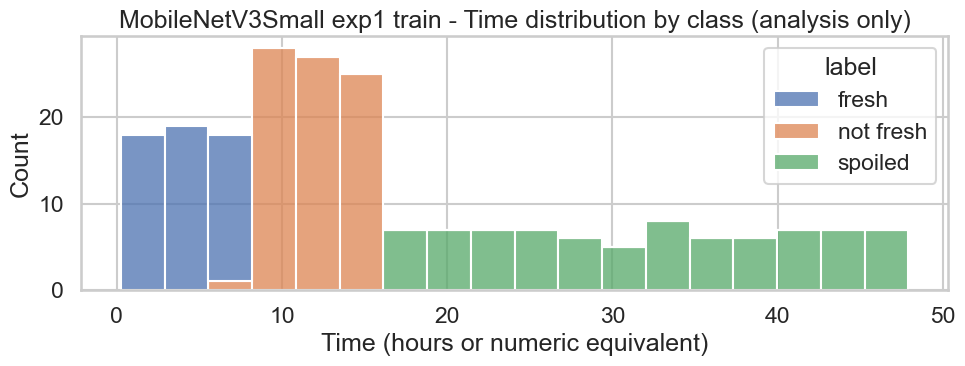


MobileNetV3Small exp1 val - class distribution


,label,count
0,fresh,9
1,not fresh,14
2,spoiled,14


MobileNetV3Small exp1 val - images per sample_number


,sample_number,image_count
0,1,37


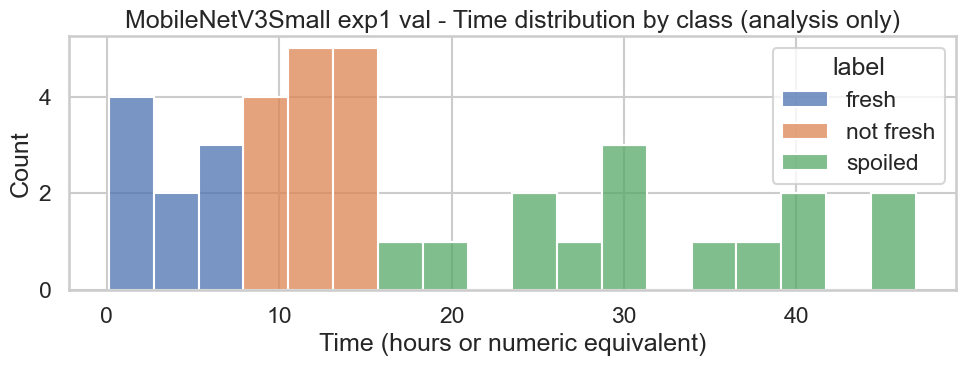


MobileNetV3Small exp1 test - class distribution


,label,count
0,fresh,93
1,not fresh,96
2,spoiled,87


MobileNetV3Small exp1 test - images per sample_number


,sample_number,image_count
0,2,276


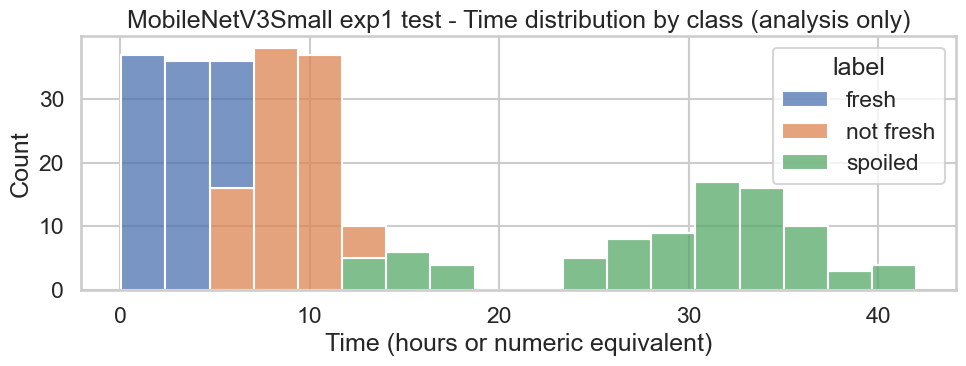

Computed class weights: {0: 1.3271604938271604, 1: 0.8847736625514403, 2: 0.8958333333333334}
Epoch 1/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3535 - loss: 1.1781 - val_accuracy: 0.3243 - val_loss: 1.0582 - learning_rate: 0.0010 - val_f1_macro: 0.2649
Epoch 2/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 0.4140 - loss: 1.0717 - val_accuracy: 0.5946 - val_loss: 0.8865 - learning_rate: 0.0010 - val_f1_macro: 0.5532
Epoch 3/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.5116 - loss: 0.9389 - val_accuracy: 0.5946 - val_loss: 0.8179 - learning_rate: 0.0010 - val_f1_macro: 0.5546
Epoch 4/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.4558 - loss: 0.9550 - val_accuracy: 0.7297 - val_loss: 0.7259 - learning_rate: 0.0010 - val_f1_macro: 0.7422
Epoch 5/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.5442 - loss: 0.8698 - val_accuracy: 0.6486 - val_loss: 0.7437 - learning_rate: 0.0010 - val_f1_macro: 0.6264
Epoch 6/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step

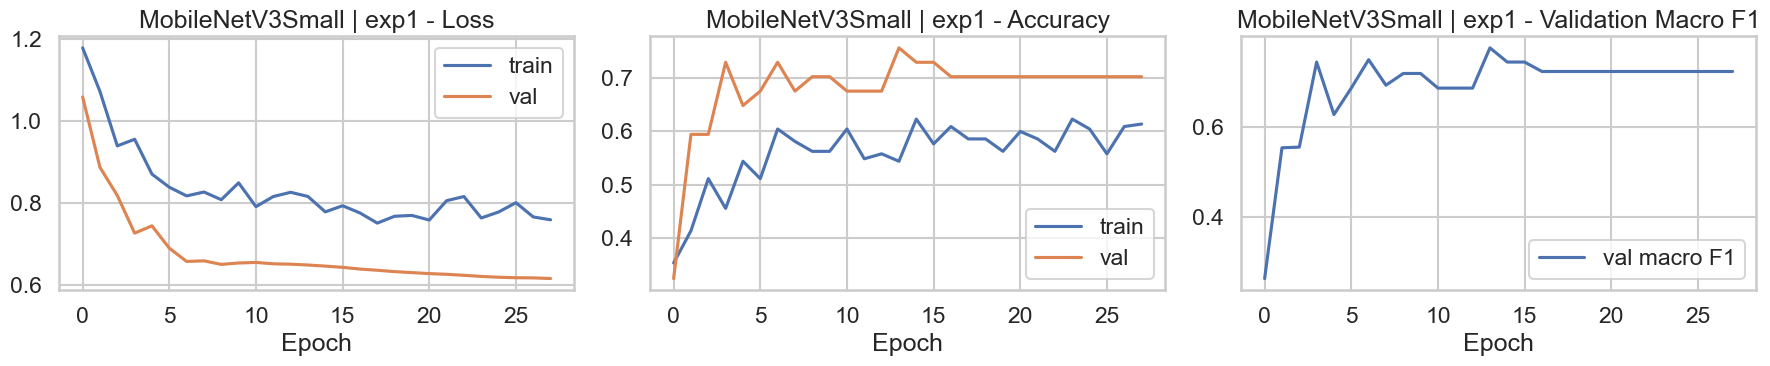


MobileNetV3Small | exp1 classification report:
              precision    recall  f1-score   support

       fresh       1.00      0.32      0.49        93
   not fresh       0.00      0.00      0.00        96
     spoiled       0.36      0.99      0.53        87

    accuracy                           0.42       276
   macro avg       0.45      0.44      0.34       276
weighted avg       0.45      0.42      0.33       276



,precision,recall,f1-score,support
fresh,1.000000,0.322581,0.487805,93.00000
not fresh,0.000000,0.000000,0.000000,96.00000
spoiled,0.359833,0.988506,0.527607,87.00000
accuracy,0.420290,0.420290,0.420290,0.42029
macro avg,0.453278,0.437029,0.338471,276.00000
weighted avg,0.450382,0.420290,0.330680,276.00000


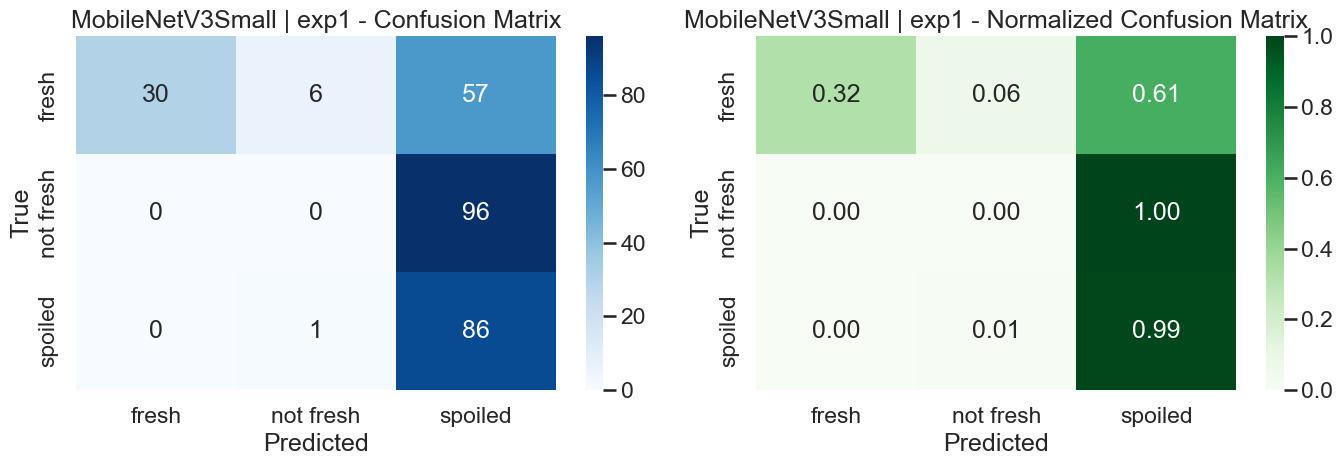

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp594ecz5v\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp594ecz5v\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmp594ecz5v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_4389')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2014849748432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849748240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849747280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849747664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849747472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849749008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849748048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849747856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849748816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014849746320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,label,count
0,fresh,79
1,not fresh,82
2,spoiled,74


MobileNetV3Small exp2 train - images per sample_number


,sample_number,image_count
0,2,235


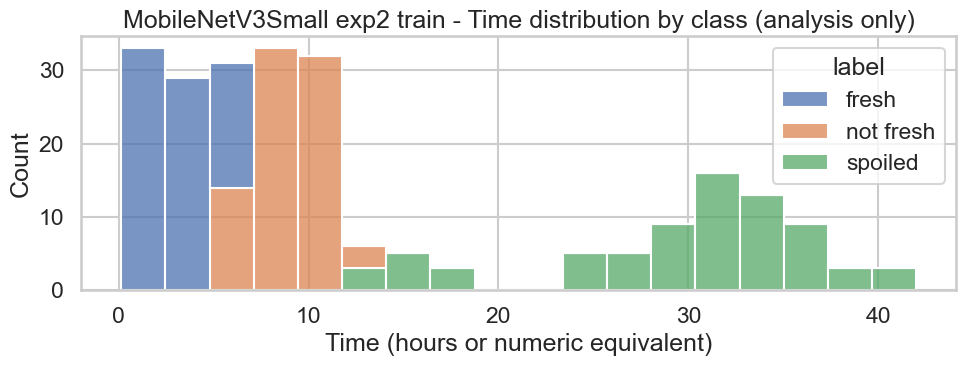


MobileNetV3Small exp2 val - class distribution


,label,count
0,fresh,14
1,not fresh,14
2,spoiled,13


MobileNetV3Small exp2 val - images per sample_number


,sample_number,image_count
0,2,41


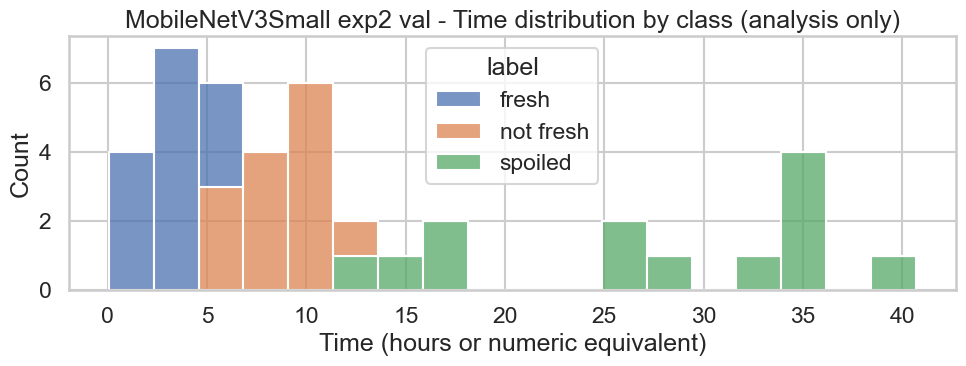


MobileNetV3Small exp2 test - class distribution


,label,count
0,fresh,63
1,not fresh,95
2,spoiled,94


MobileNetV3Small exp2 test - images per sample_number


,sample_number,image_count
0,1,252


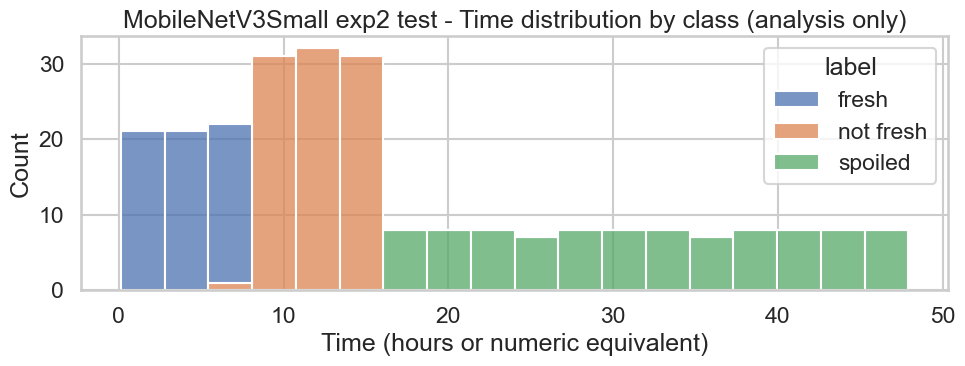

Computed class weights: {0: 0.9915611814345991, 1: 0.9552845528455285, 2: 1.0585585585585586}
Epoch 1/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 815ms/step - accuracy: 0.3872 - loss: 1.1229 - val_accuracy: 0.3415 - val_loss: 1.0428 - learning_rate: 0.0010 - val_f1_macro: 0.1697
Epoch 2/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.3532 - loss: 1.0659 - val_accuracy: 0.4146 - val_loss: 1.0380 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 3/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.4255 - loss: 1.0422 - val_accuracy: 0.4634 - val_loss: 0.9955 - learning_rate: 0.0010 - val_f1_macro: 0.3621
Epoch 4/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.4085 - loss: 1.0362 - val_accuracy: 0.4390 - val_loss: 1.0000 - learning_rate: 0.0010 - val_f1_macro: 0.3348
Epoch 5/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.4681 - loss: 0.9985 - val_accuracy: 0.3902 - val_loss: 1.0107 - learning_rate: 0.0010 - val_f1_macro: 0.2876
Epoch 6/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/s

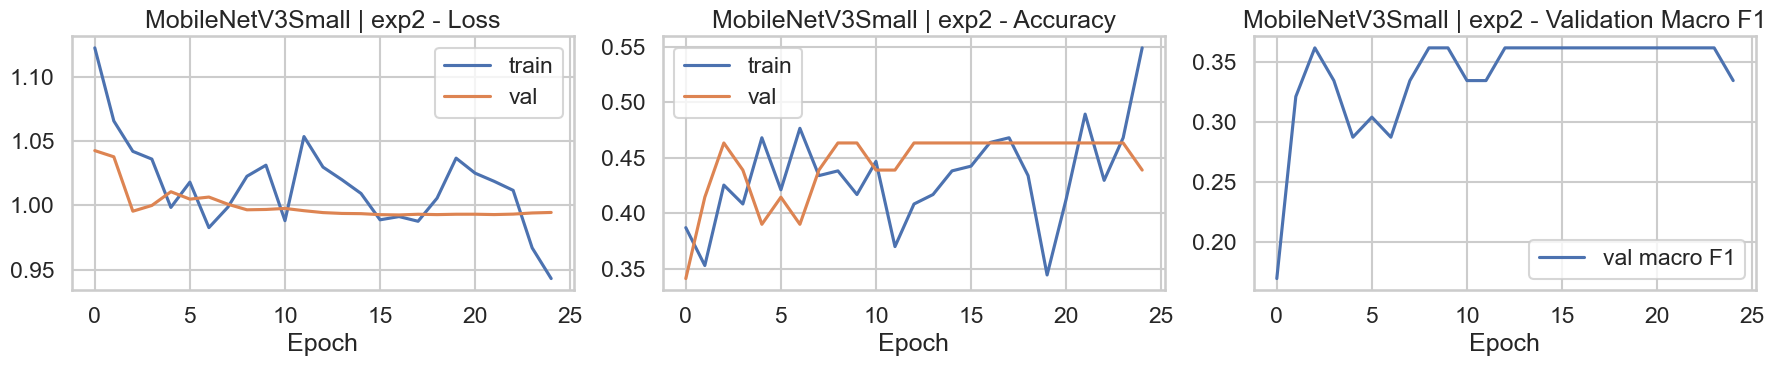


MobileNetV3Small | exp2 classification report:
              precision    recall  f1-score   support

       fresh       0.25      1.00      0.40        63
   not fresh       1.00      0.01      0.02        95
     spoiled       0.00      0.00      0.00        94

    accuracy                           0.25       252
   macro avg       0.42      0.34      0.14       252
weighted avg       0.44      0.25      0.11       252



,precision,recall,f1-score,support
fresh,0.250996,1.000000,0.401274,63.000000
not fresh,1.000000,0.010526,0.020833,95.000000
spoiled,0.000000,0.000000,0.000000,94.000000
accuracy,0.253968,0.253968,0.253968,0.253968
macro avg,0.416999,0.336842,0.140702,252.000000
weighted avg,0.439733,0.253968,0.108172,252.000000


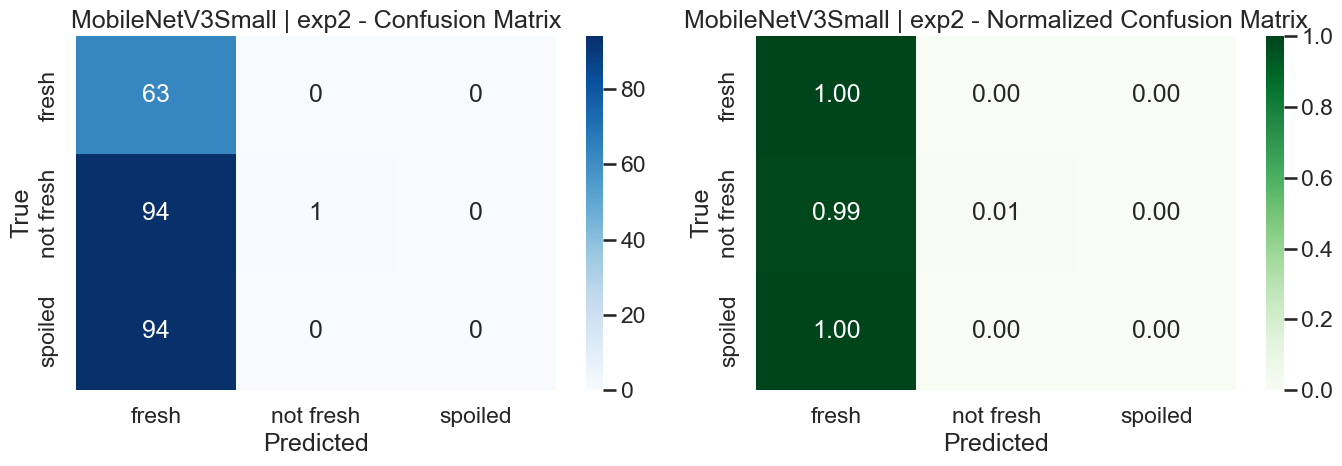

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpv_c_1dbb\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpv_c_1dbb\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmpv_c_1dbb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_4571')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2012533950800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055758160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055758352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055757968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2014055756048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,label,count
0,fresh,54
1,not fresh,81
2,spoiled,80


EfficientNetB0 exp1 train - images per sample_number


,sample_number,image_count
0,1,215


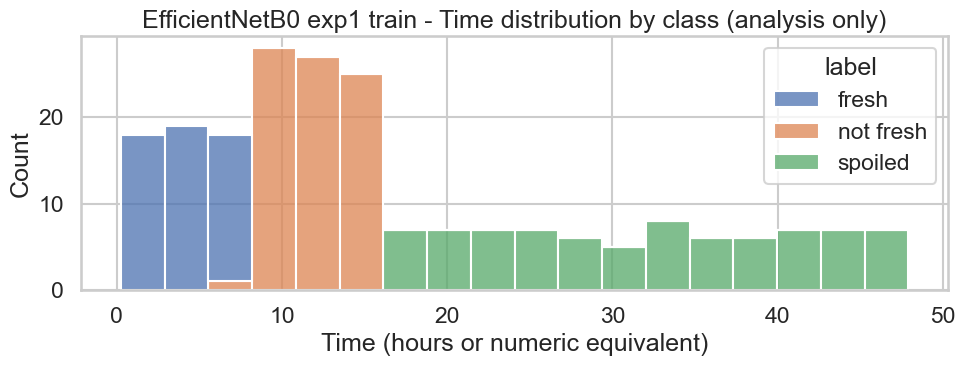


EfficientNetB0 exp1 val - class distribution


,label,count
0,fresh,9
1,not fresh,14
2,spoiled,14


EfficientNetB0 exp1 val - images per sample_number


,sample_number,image_count
0,1,37


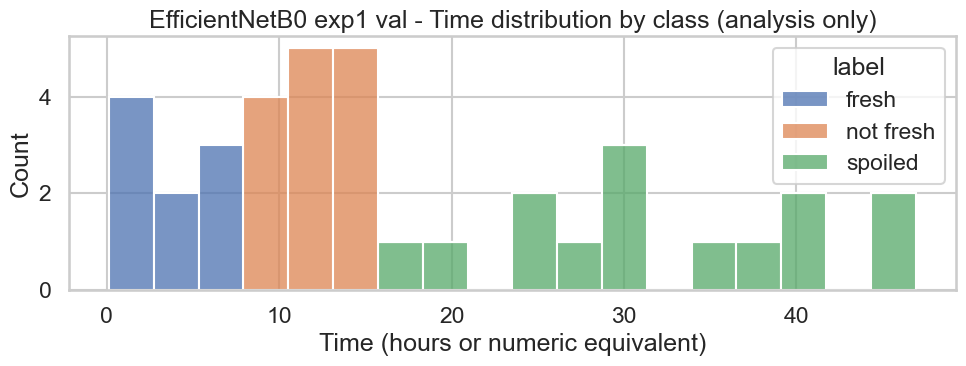


EfficientNetB0 exp1 test - class distribution


,label,count
0,fresh,93
1,not fresh,96
2,spoiled,87


EfficientNetB0 exp1 test - images per sample_number


,sample_number,image_count
0,2,276


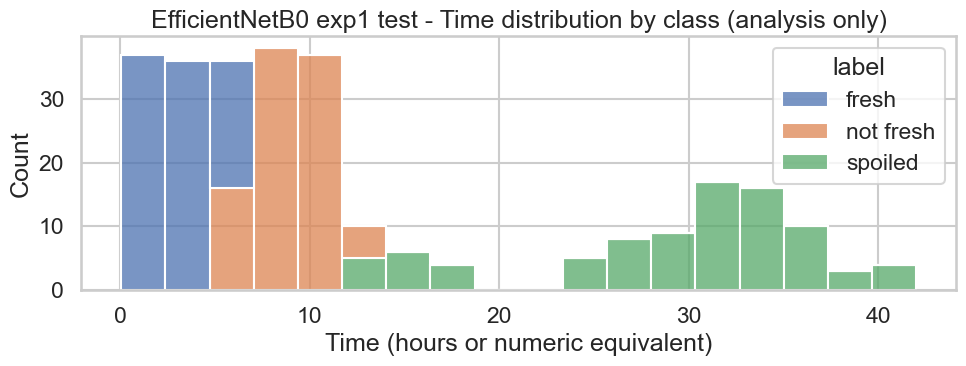

Computed class weights: {0: 1.3271604938271604, 1: 0.8847736625514403, 2: 0.8958333333333334}
Epoch 1/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4233 - loss: 1.0748 - val_accuracy: 0.4865 - val_loss: 0.9428 - learning_rate: 0.0010 - val_f1_macro: 0.4000
Epoch 2/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 998ms/step - accuracy: 0.5395 - loss: 0.9297 - val_accuracy: 0.7568 - val_loss: 0.7244 - learning_rate: 0.0010 - val_f1_macro: 0.7729
Epoch 3/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 805ms/step - accuracy: 0.5116 - loss: 0.8862 - val_accuracy: 0.5135 - val_loss: 0.8042 - learning_rate: 0.0010 - val_f1_macro: 0.4785
Epoch 4/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 978ms/step - accuracy: 0.5209 - loss: 0.8647 - val_accuracy: 0.6757 - val_loss: 0.6371 - learning_rate: 0.0010 - val_f1_macro: 0.7025
Epoch 5/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step - accuracy: 0.5767 - loss: 0.8722 - val_accuracy: 0.5676 - val_loss: 0.6936 - learning_rate: 0.0010 - val_f1_macro: 0.5609
Epoch 6/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 980ms/step

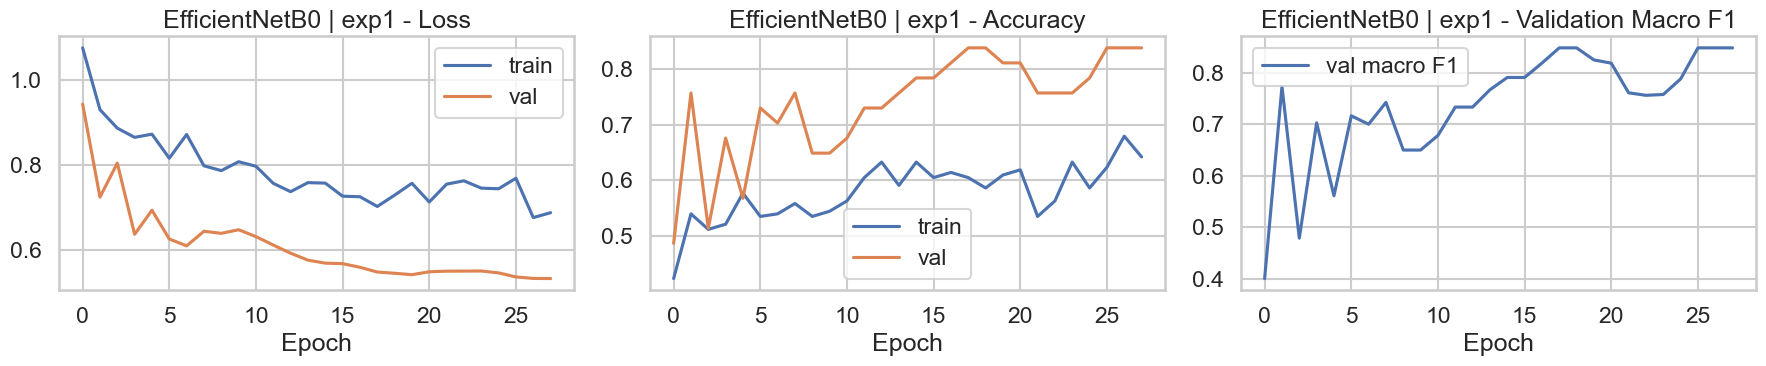


EfficientNetB0 | exp1 classification report:
              precision    recall  f1-score   support

       fresh       0.97      0.38      0.54        93
   not fresh       0.40      1.00      0.57        96
     spoiled       0.00      0.00      0.00        87

    accuracy                           0.47       276
   macro avg       0.46      0.46      0.37       276
weighted avg       0.47      0.47      0.38       276



,precision,recall,f1-score,support
fresh,0.972222,0.376344,0.542636,93.000000
not fresh,0.400000,1.000000,0.571429,96.000000
spoiled,0.000000,0.000000,0.000000,87.000000
accuracy,0.474638,0.474638,0.474638,0.474638
macro avg,0.457407,0.458781,0.371355,276.000000
weighted avg,0.466727,0.474638,0.381602,276.000000


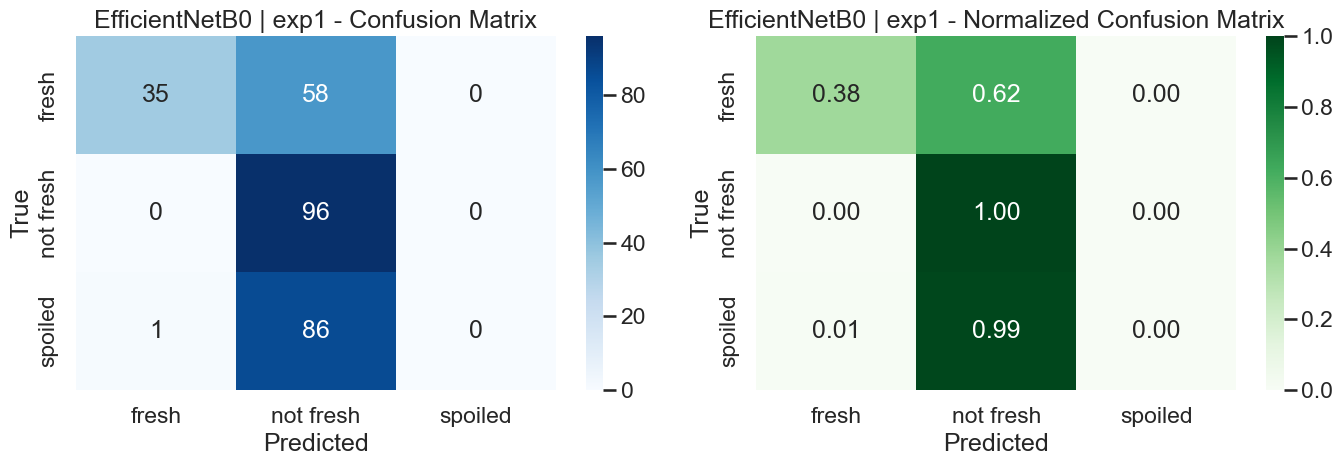

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpmie503z2\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpmie503z2\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmpmie503z2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_4816')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2020155301264: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2020155302608: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2020230689424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230677520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230676944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230688272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230691152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020230687888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020150056464: TensorSpec(shape=(), dtype=tf.resou

,label,count
0,fresh,79
1,not fresh,82
2,spoiled,74


EfficientNetB0 exp2 train - images per sample_number


,sample_number,image_count
0,2,235


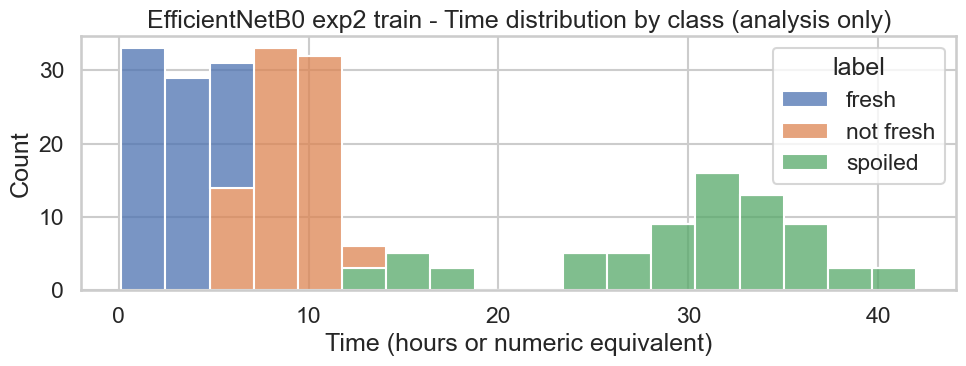


EfficientNetB0 exp2 val - class distribution


,label,count
0,fresh,14
1,not fresh,14
2,spoiled,13


EfficientNetB0 exp2 val - images per sample_number


,sample_number,image_count
0,2,41


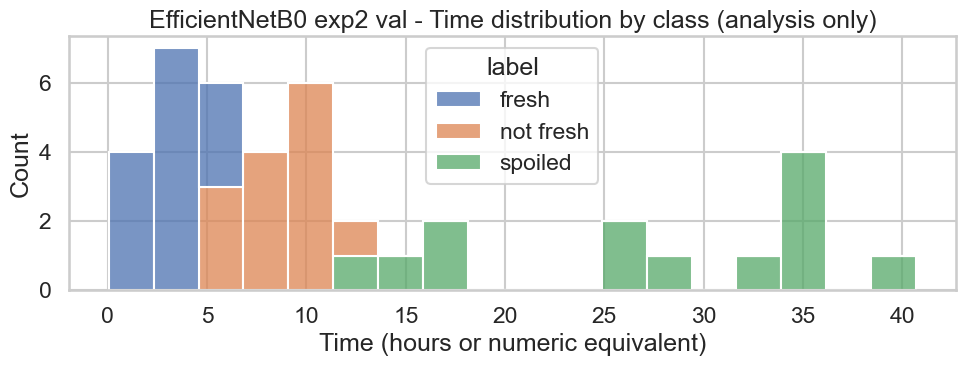


EfficientNetB0 exp2 test - class distribution


,label,count
0,fresh,63
1,not fresh,95
2,spoiled,94


EfficientNetB0 exp2 test - images per sample_number


,sample_number,image_count
0,1,252


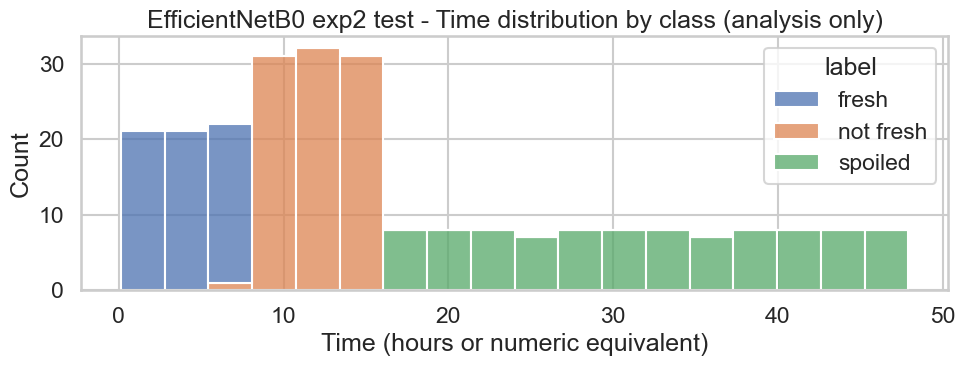

Computed class weights: {0: 0.9915611814345991, 1: 0.9552845528455285, 2: 1.0585585585585586}
Epoch 1/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.3021 - loss: 1.1474 - val_accuracy: 0.3415 - val_loss: 1.0398 - learning_rate: 0.0010 - val_f1_macro: 0.1697
Epoch 2/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 924ms/step - accuracy: 0.3957 - loss: 1.0451 - val_accuracy: 0.4390 - val_loss: 1.0289 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 3/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 919ms/step - accuracy: 0.4255 - loss: 1.0295 - val_accuracy: 0.4390 - val_loss: 0.9961 - learning_rate: 0.0010 - val_f1_macro: 0.3523
Epoch 4/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 766ms/step - accuracy: 0.4340 - loss: 1.0253 - val_accuracy: 0.4390 - val_loss: 1.0069 - learning_rate: 0.0010 - val_f1_macro: 0.3348
Epoch 5/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 773ms/step - accuracy: 0.4255 - loss: 1.0001 - val_accuracy: 0.4146 - val_loss: 1.0228 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 6/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 768ms/step

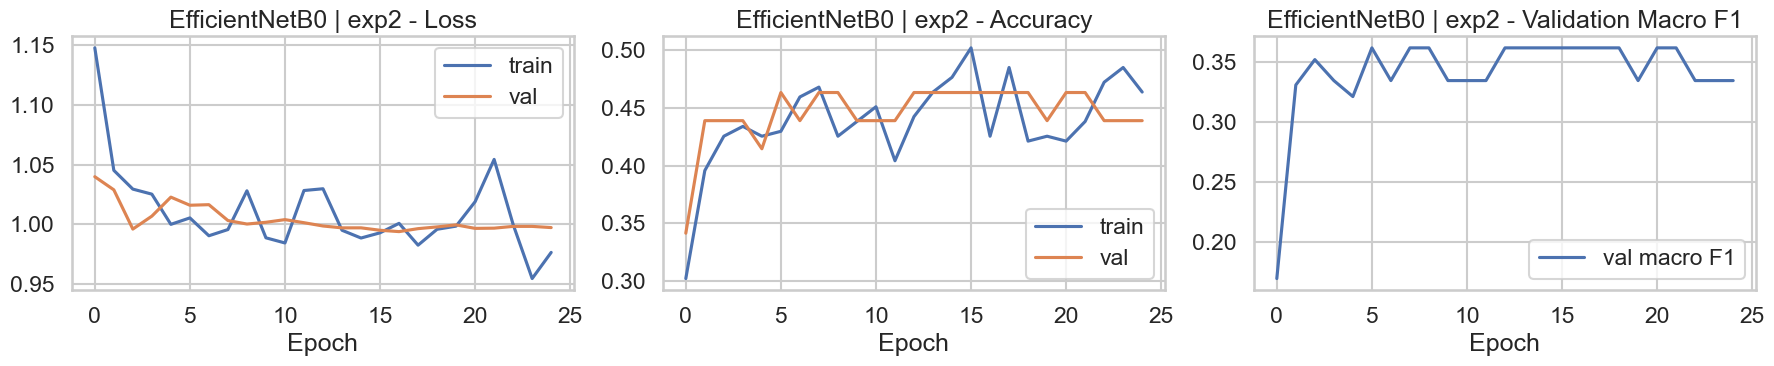


EfficientNetB0 | exp2 classification report:
              precision    recall  f1-score   support

       fresh       0.25      1.00      0.40        63
   not fresh       1.00      0.01      0.02        95
     spoiled       0.00      0.00      0.00        94

    accuracy                           0.25       252
   macro avg       0.42      0.34      0.14       252
weighted avg       0.44      0.25      0.11       252



,precision,recall,f1-score,support
fresh,0.250996,1.000000,0.401274,63.000000
not fresh,1.000000,0.010526,0.020833,95.000000
spoiled,0.000000,0.000000,0.000000,94.000000
accuracy,0.253968,0.253968,0.253968,0.253968
macro avg,0.416999,0.336842,0.140702,252.000000
weighted avg,0.439733,0.253968,0.108172,252.000000


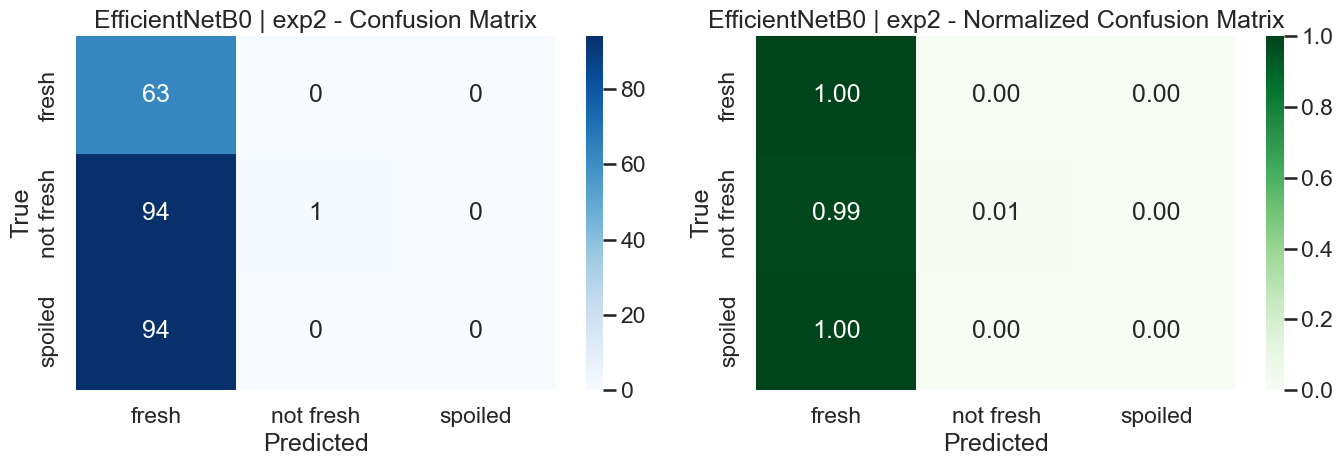

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpta9m4xep\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpta9m4xep\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmpta9m4xep'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5061')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2021942806480: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2021942807824: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2020155304720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155305488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155306640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155294736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155303952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155302032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155304912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2020155303184: TensorSpec(shape=(), dtype=tf.resou

,label,count
0,fresh,54
1,not fresh,81
2,spoiled,80


ResNet50 exp1 train - images per sample_number


,sample_number,image_count
0,1,215


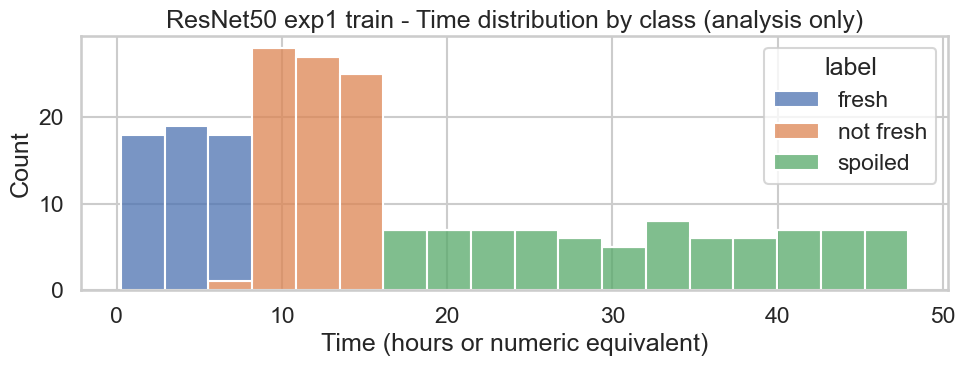


ResNet50 exp1 val - class distribution


,label,count
0,fresh,9
1,not fresh,14
2,spoiled,14


ResNet50 exp1 val - images per sample_number


,sample_number,image_count
0,1,37


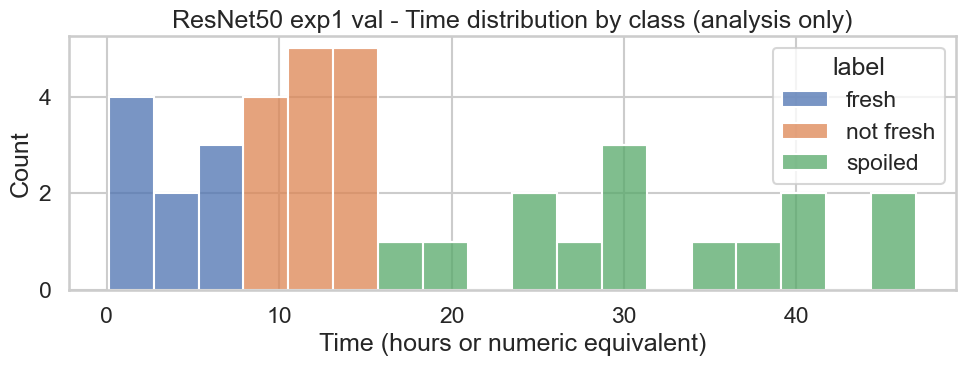


ResNet50 exp1 test - class distribution


,label,count
0,fresh,93
1,not fresh,96
2,spoiled,87


ResNet50 exp1 test - images per sample_number


,sample_number,image_count
0,2,276


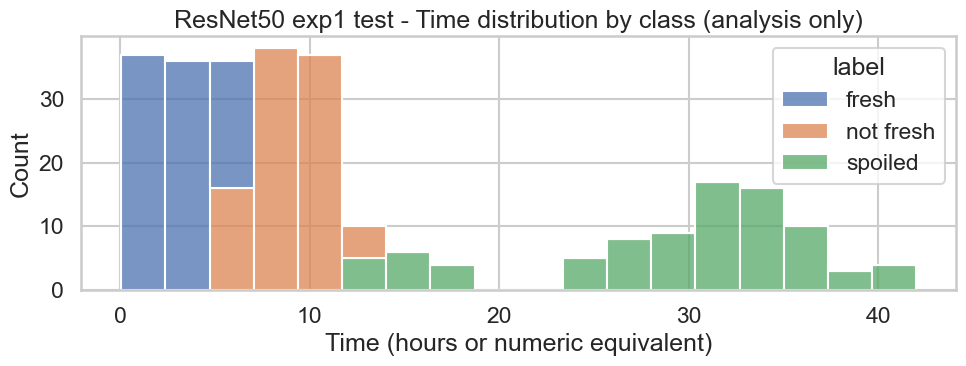

Computed class weights: {0: 1.3271604938271604, 1: 0.8847736625514403, 2: 0.8958333333333334}
Epoch 1/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4698 - loss: 1.1090 - val_accuracy: 0.5946 - val_loss: 1.0105 - learning_rate: 0.0010 - val_f1_macro: 0.5308
Epoch 2/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5349 - loss: 0.8728 - val_accuracy: 0.7297 - val_loss: 0.6932 - learning_rate: 0.0010 - val_f1_macro: 0.7198
Epoch 3/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5442 - loss: 0.9510 - val_accuracy: 0.6216 - val_loss: 0.8082 - learning_rate: 0.0010 - val_f1_macro: 0.5980
Epoch 4/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5256 - loss: 0.8784 - val_accuracy: 0.6486 - val_loss: 0.7669 - learning_rate: 0.0010 - val_f1_macro: 0.6130
Epoch 5/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5628 - loss: 0.9237 - val_accuracy: 0.5946 - val_loss: 0.8379 - learning_rate: 0.0010 - val_f1_macro: 0.5171
Epoch 6/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accurac

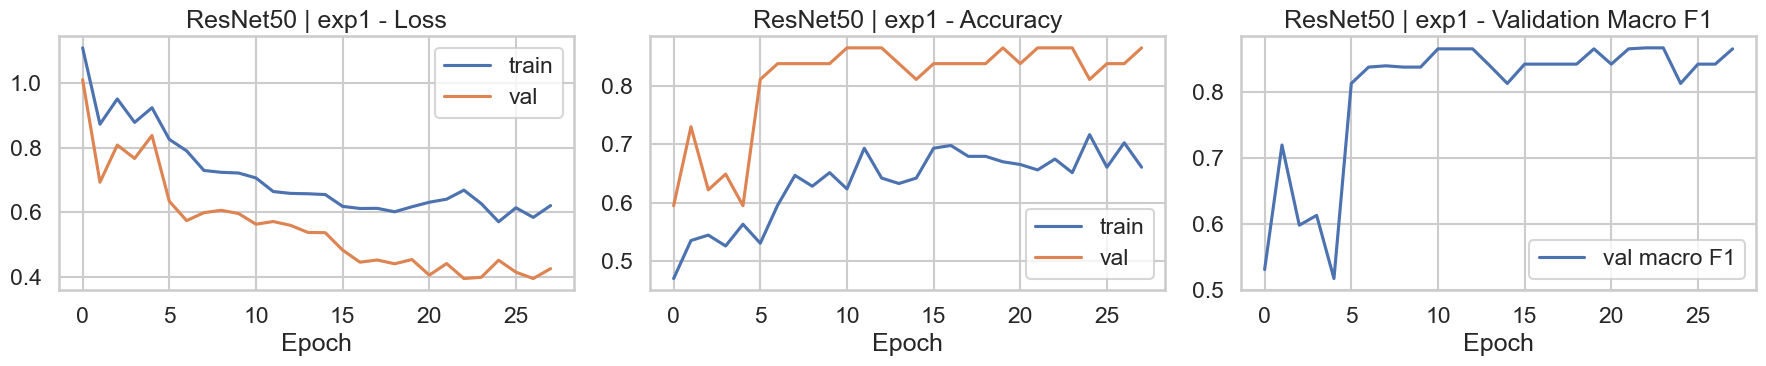


ResNet50 | exp1 classification report:
              precision    recall  f1-score   support

       fresh       1.00      0.39      0.56        93
   not fresh       0.00      0.00      0.00        96
     spoiled       0.36      0.98      0.52        87

    accuracy                           0.44       276
   macro avg       0.45      0.45      0.36       276
weighted avg       0.45      0.44      0.35       276



,precision,recall,f1-score,support
fresh,1.000000,0.387097,0.558140,93.000000
not fresh,0.000000,0.000000,0.000000,96.000000
spoiled,0.357143,0.977011,0.523077,87.000000
accuracy,0.438406,0.438406,0.438406,0.438406
macro avg,0.452381,0.454703,0.360405,276.000000
weighted avg,0.449534,0.438406,0.352952,276.000000


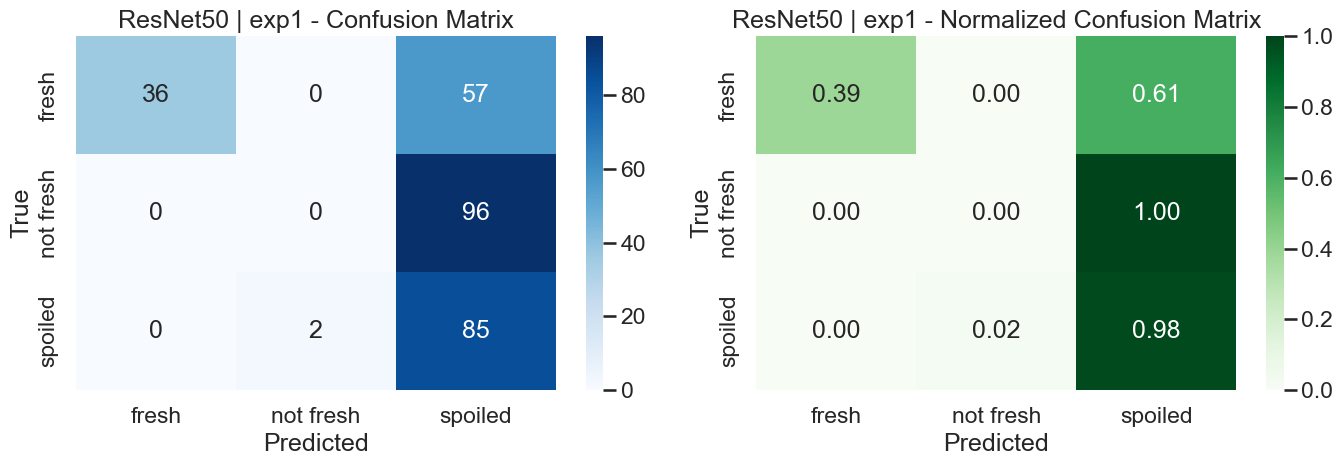

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpu5lqml4t\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpu5lqml4t\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmpu5lqml4t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5243')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2021942811472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942810512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942808784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942804560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942808400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942810320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942809744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2021942807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024938075728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024938077072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,label,count
0,fresh,79
1,not fresh,82
2,spoiled,74


ResNet50 exp2 train - images per sample_number


,sample_number,image_count
0,2,235


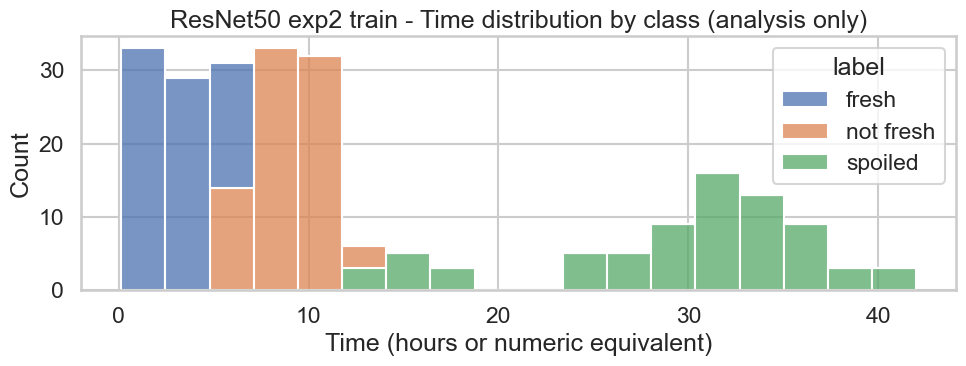


ResNet50 exp2 val - class distribution


,label,count
0,fresh,14
1,not fresh,14
2,spoiled,13


ResNet50 exp2 val - images per sample_number


,sample_number,image_count
0,2,41


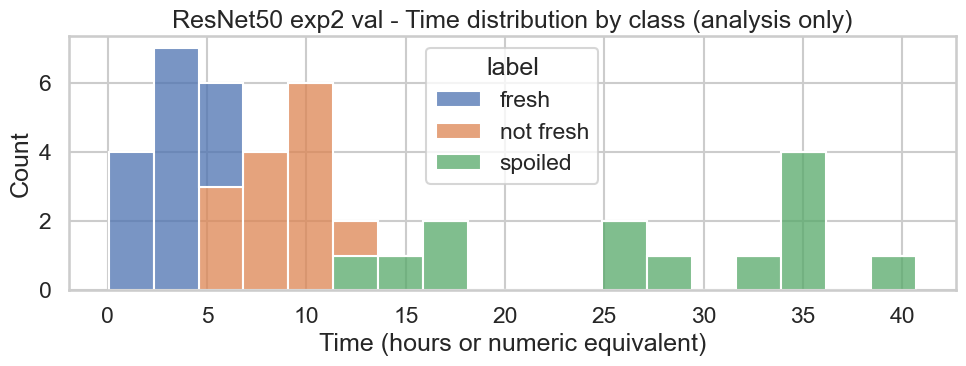


ResNet50 exp2 test - class distribution


,label,count
0,fresh,63
1,not fresh,95
2,spoiled,94


ResNet50 exp2 test - images per sample_number


,sample_number,image_count
0,1,252


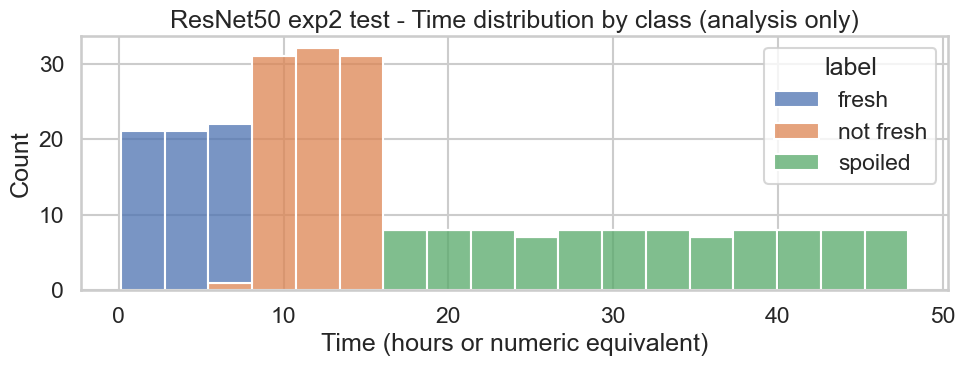

Computed class weights: {0: 0.9915611814345991, 1: 0.9552845528455285, 2: 1.0585585585585586}
Epoch 1/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.3404 - loss: 1.1778 - val_accuracy: 0.4146 - val_loss: 1.0012 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 2/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4085 - loss: 1.0608 - val_accuracy: 0.4390 - val_loss: 1.0027 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 3/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4596 - loss: 1.0110 - val_accuracy: 0.4390 - val_loss: 1.0007 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 4/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4426 - loss: 1.0121 - val_accuracy: 0.4146 - val_loss: 0.9936 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 5/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3957 - loss: 1.0137 - val_accuracy: 0.4390 - val_loss: 1.0026 - learning_rate: 0.0010 - val_f1_macro: 0.3523
Epoch 6/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accurac

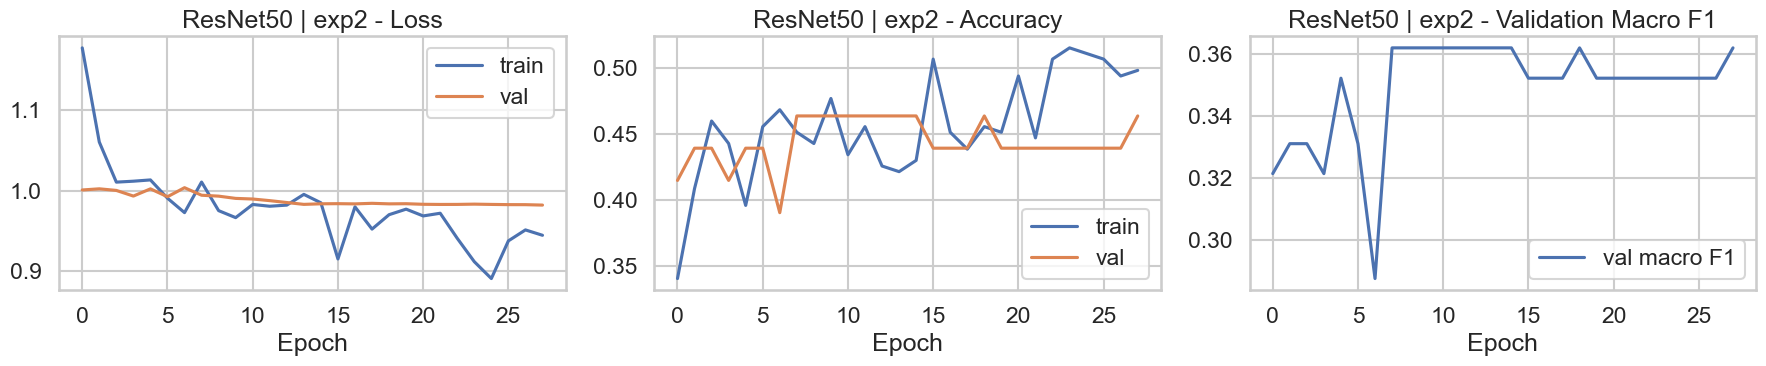


ResNet50 | exp2 classification report:
              precision    recall  f1-score   support

       fresh       0.74      0.86      0.79        63
   not fresh       1.00      0.01      0.02        95
     spoiled       0.51      0.96      0.66        94

    accuracy                           0.58       252
   macro avg       0.75      0.61      0.49       252
weighted avg       0.75      0.58      0.45       252



,precision,recall,f1-score,support
fresh,0.739726,0.857143,0.794118,63.000000
not fresh,1.000000,0.010526,0.020833,95.000000
spoiled,0.505618,0.957447,0.661765,94.000000
accuracy,0.575397,0.575397,0.575397,0.575397
macro avg,0.748448,0.608372,0.492239,252.000000
weighted avg,0.750519,0.575397,0.453232,252.000000


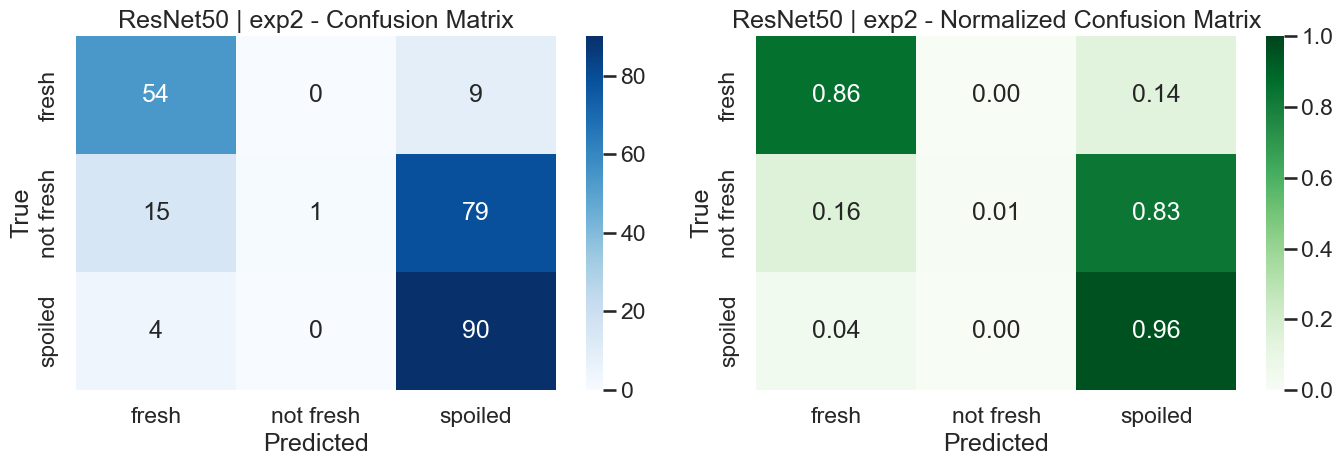

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp0qr3jw2n\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp0qr3jw2n\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmp0qr3jw2n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5425')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2024980738896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980737552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980736976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980736016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980736592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980736208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980735440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980737168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980737936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2024980732368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,label,count
0,fresh,54
1,not fresh,81
2,spoiled,80


MobileNetV2 exp1 train - images per sample_number


,sample_number,image_count
0,1,215


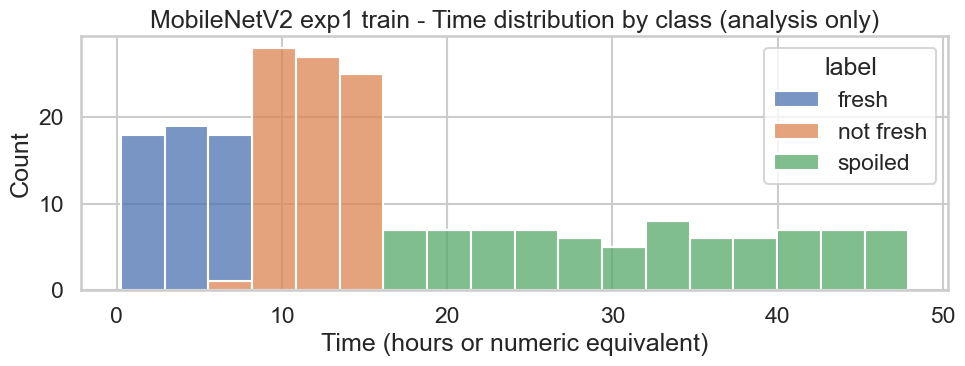


MobileNetV2 exp1 val - class distribution


,label,count
0,fresh,9
1,not fresh,14
2,spoiled,14


MobileNetV2 exp1 val - images per sample_number


,sample_number,image_count
0,1,37


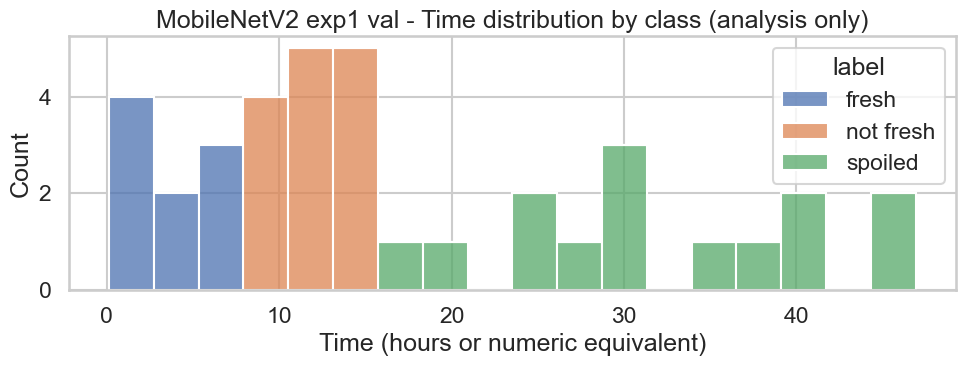


MobileNetV2 exp1 test - class distribution


,label,count
0,fresh,93
1,not fresh,96
2,spoiled,87


MobileNetV2 exp1 test - images per sample_number


,sample_number,image_count
0,2,276


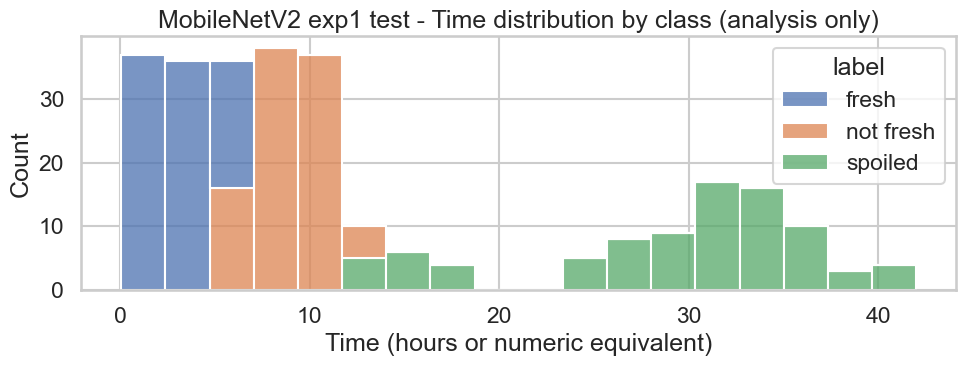

Computed class weights: {0: 1.3271604938271604, 1: 0.8847736625514403, 2: 0.8958333333333334}
Epoch 1/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3488 - loss: 1.3353 - val_accuracy: 0.7027 - val_loss: 0.8116 - learning_rate: 0.0010 - val_f1_macro: 0.7060
Epoch 2/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 715ms/step - accuracy: 0.4837 - loss: 0.9932 - val_accuracy: 0.8108 - val_loss: 0.6480 - learning_rate: 0.0010 - val_f1_macro: 0.8239
Epoch 3/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 722ms/step - accuracy: 0.4884 - loss: 0.9388 - val_accuracy: 0.6216 - val_loss: 0.6228 - learning_rate: 0.0010 - val_f1_macro: 0.5769
Epoch 4/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.5070 - loss: 0.9601 - val_accuracy: 0.8108 - val_loss: 0.5615 - learning_rate: 0.0010 - val_f1_macro: 0.8185
Epoch 5/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 715ms/step - accuracy: 0.5023 - loss: 1.0254 - val_accuracy: 0.8108 - val_loss: 0.5594 - learning_rate: 0.0010 - val_f1_macro: 0.8228
Epoch 6/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 711ms/step

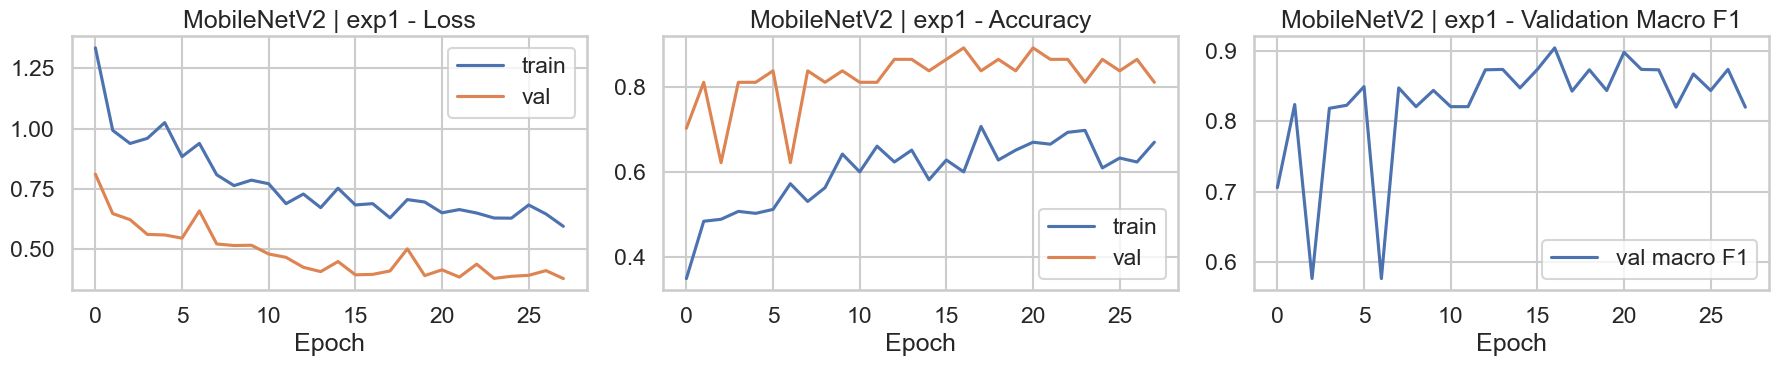


MobileNetV2 | exp1 classification report:
              precision    recall  f1-score   support

       fresh       1.00      0.25      0.40        93
   not fresh       0.40      1.00      0.57        96
     spoiled       0.00      0.00      0.00        87

    accuracy                           0.43       276
   macro avg       0.47      0.42      0.32       276
weighted avg       0.47      0.43      0.33       276



,precision,recall,f1-score,support
fresh,1.000000,0.247312,0.396552,93.000000
not fresh,0.396694,1.000000,0.568047,96.000000
spoiled,0.000000,0.000000,0.000000,87.000000
accuracy,0.431159,0.431159,0.431159,0.431159
macro avg,0.465565,0.415771,0.321533,276.000000
weighted avg,0.474937,0.431159,0.331202,276.000000


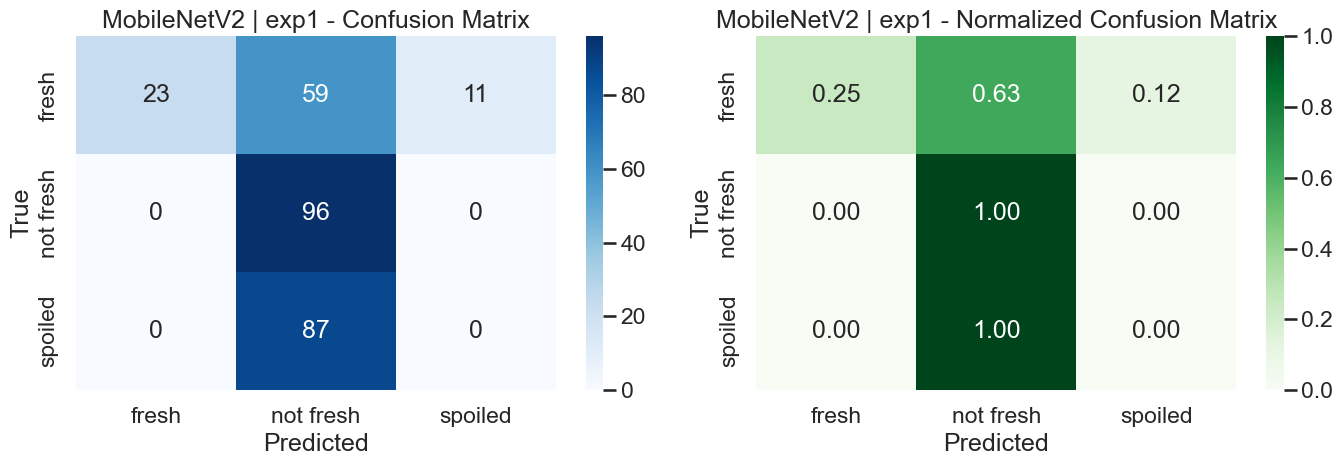

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp136tolj9\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp136tolj9\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmp136tolj9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5586')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2025254170128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254168016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254168208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254168592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254163024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254169936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254167440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254167824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254169360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025254164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,label,count
0,fresh,79
1,not fresh,82
2,spoiled,74


MobileNetV2 exp2 train - images per sample_number


,sample_number,image_count
0,2,235


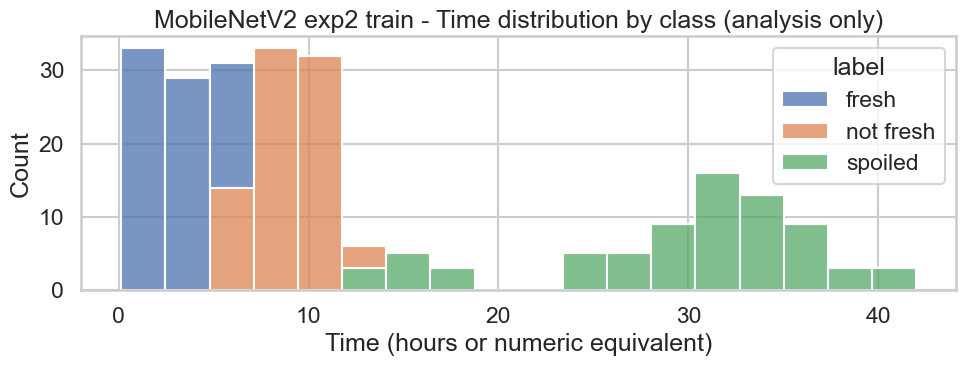


MobileNetV2 exp2 val - class distribution


,label,count
0,fresh,14
1,not fresh,14
2,spoiled,13


MobileNetV2 exp2 val - images per sample_number


,sample_number,image_count
0,2,41


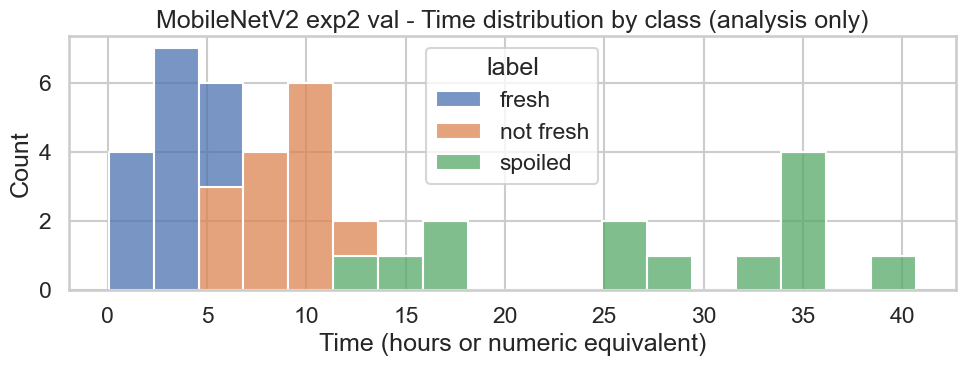


MobileNetV2 exp2 test - class distribution


,label,count
0,fresh,63
1,not fresh,95
2,spoiled,94


MobileNetV2 exp2 test - images per sample_number


,sample_number,image_count
0,1,252


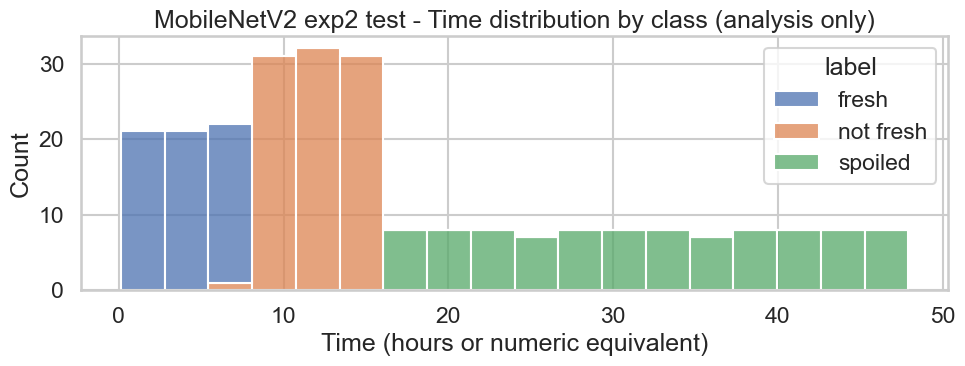

Computed class weights: {0: 0.9915611814345991, 1: 0.9552845528455285, 2: 1.0585585585585586}
Epoch 1/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3660 - loss: 1.3282 - val_accuracy: 0.4390 - val_loss: 1.0452 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 2/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 622ms/step - accuracy: 0.4553 - loss: 1.0899 - val_accuracy: 0.4146 - val_loss: 1.0473 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 3/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 680ms/step - accuracy: 0.4085 - loss: 1.0465 - val_accuracy: 0.4390 - val_loss: 1.0324 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 4/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 679ms/step - accuracy: 0.4468 - loss: 1.0844 - val_accuracy: 0.4146 - val_loss: 1.0030 - learning_rate: 0.0010 - val_f1_macro: 0.3215
Epoch 5/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 677ms/step - accuracy: 0.3447 - loss: 1.0729 - val_accuracy: 0.4390 - val_loss: 1.0011 - learning_rate: 0.0010 - val_f1_macro: 0.3312
Epoch 6/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 706ms/step

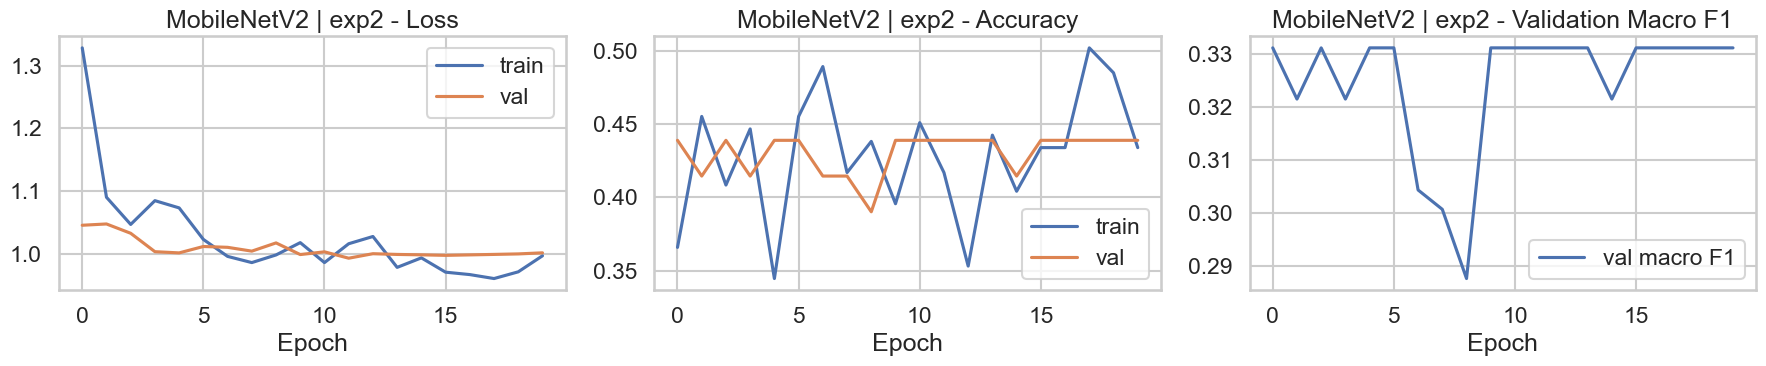


MobileNetV2 | exp2 classification report:
              precision    recall  f1-score   support

       fresh       0.31      1.00      0.47        63
   not fresh       1.00      0.01      0.02        95
     spoiled       0.82      0.39      0.53        94

    accuracy                           0.40       252
   macro avg       0.71      0.47      0.34       252
weighted avg       0.76      0.40      0.32       252



,precision,recall,f1-score,support
fresh,0.305825,1.000000,0.468401,63.000000
not fresh,1.000000,0.010526,0.020833,95.000000
spoiled,0.822222,0.393617,0.532374,94.000000
accuracy,0.400794,0.400794,0.400794,0.400794
macro avg,0.709349,0.468048,0.340536,252.000000
weighted avg,0.760142,0.400794,0.323538,252.000000


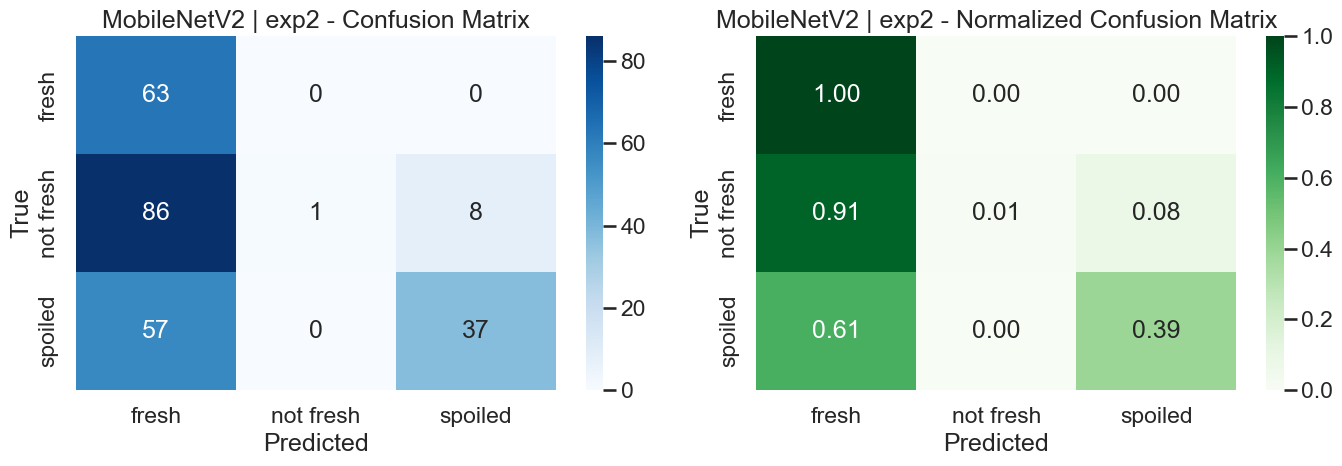

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpz39qts7y\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpz39qts7y\assets


Saved artifact at 'C:\Users\jazre\AppData\Local\Temp\tmpz39qts7y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5747')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2025626169232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626167312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626166928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626167696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626167120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626167888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626165200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626165008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626169424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025626166160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

,backbone,experiment,train_count,val_count,test_count,missing_train,missing_val,missing_test,accuracy,precision_macro,recall_macro,f1_macro,h5_mb,tflite_mb
0,EfficientNetB0,exp1,215,37,276,0,0,0,0.474638,0.457407,0.458781,0.371355,16.528984,15.950516
1,EfficientNetB0,exp2,235,41,252,0,0,0,0.253968,0.416999,0.336842,0.140702,16.528984,15.950516
2,MobileNetV2,exp1,215,37,276,0,0,0,0.431159,0.465565,0.415771,0.321533,9.594147,9.105366
3,MobileNetV2,exp2,235,41,252,0,0,0,0.400794,0.709349,0.468048,0.340536,9.594147,9.105366
4,MobileNetV3Small,exp1,215,37,276,0,0,0,0.420290,0.453278,0.437029,0.338471,4.176521,3.866657
5,MobileNetV3Small,exp2,235,41,252,0,0,0,0.253968,0.416999,0.336842,0.140702,4.176521,3.866657
6,ResNet50,exp1,215,37,276,0,0,0,0.438406,0.452381,0.454703,0.360405,91.361755,90.632618
7,ResNet50,exp2,235,41,252,0,0,0,0.575397,0.748448,0.608372,0.492239,91.361755,90.632618


Average metrics by backbone:


,backbone,accuracy,precision_macro,recall_macro,f1_macro,h5_mb,tflite_mb
0,ResNet50,0.506901,0.600414,0.531537,0.426322,91.361755,90.632618
1,MobileNetV2,0.415977,0.587457,0.441909,0.331035,9.594147,9.105366
2,EfficientNetB0,0.364303,0.437203,0.397812,0.256029,16.528984,15.950516
3,MobileNetV3Small,0.337129,0.435138,0.386935,0.239587,4.176521,3.866657


Best run by macro F1: {'backbone': 'ResNet50', 'experiment': 'exp2', 'train_count': 235, 'val_count': 41, 'test_count': 252, 'missing_train': 0, 'missing_val': 0, 'missing_test': 0, 'accuracy': 0.5753968253968254, 'precision_macro': 0.7484480016417834, 'recall_macro': 0.608371993814323, 'f1_macro': 0.49223856209150324, 'h5_mb': 91.36175537109375, 'tflite_mb': 90.63261795043945}
Best backbone by average macro F1: {'backbone': 'ResNet50', 'accuracy': 0.5069013112491373, 'precision_macro': 0.6004144770113679, 'recall_macro': 0.5315373749815652, 'f1_macro': 0.4263220240391923, 'h5_mb': 91.36175537109375, 'tflite_mb': 90.63261795043945}


In [42]:
def artifact_prefix(backbone_name, exp_name):
    return f"meatlens_{BACKBONE_SPECS[backbone_name]['short_name']}_{exp_name}"


def save_model_artifacts(model, backbone_name, exp_name):
    prefix = artifact_prefix(backbone_name, exp_name)
    h5_path = Path(f"{prefix}.h5")
    tflite_path = Path(f"{prefix}.tflite")

    model.save(h5_path, include_optimizer=False)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_bytes = converter.convert()
    tflite_path.write_bytes(tflite_bytes)

    return {
        "h5_path": h5_path,
        "tflite_path": tflite_path,
        "h5_mb": h5_path.stat().st_size / (1024 ** 2),
        "tflite_mb": tflite_path.stat().st_size / (1024 ** 2),
    }


def run_single_experiment(backbone_name, exp_name):
    split_paths = SPLITS[exp_name]

    train_raw = load_split(split_paths["train"])
    val_raw = load_split(split_paths["val"])
    test_raw = load_split(split_paths["test"])

    train_df, train_missing = filter_existing_roi_rows(train_raw, f"{exp_name} train")
    val_df, val_missing = filter_existing_roi_rows(val_raw, f"{exp_name} val")
    test_df, test_missing = filter_existing_roi_rows(test_raw, f"{exp_name} test")

    print(f"\n{backbone_name} | {exp_name}")
    print(f"Train rows: {len(train_df)} | Val rows: {len(val_df)} | Test rows: {len(test_df)}")
    print(f"Missing ROI rows removed: train={len(train_missing)}, val={len(val_missing)}, test={len(test_missing)}")
    show_split_diagnostics(train_df, f"{backbone_name} {exp_name} train")
    show_split_diagnostics(val_df, f"{backbone_name} {exp_name} val")
    show_split_diagnostics(test_df, f"{backbone_name} {exp_name} test")

    class_weight = compute_class_weights_from_df(train_df)
    print("Computed class weights:", class_weight)

    model, backbone, preprocess_fn = build_model(backbone_name)
    train_ds = make_dataset(train_df, preprocess_fn, training=True)
    val_ds = make_dataset(val_df, preprocess_fn, training=False)
    test_ds = make_dataset(test_df, preprocess_fn, training=False)

    history_head, history_fine = train_two_phase(
        model=model,
        backbone=backbone,
        train_ds=train_ds,
        val_ds=val_ds,
        backbone_name=backbone_name,
        run_name=f"{BACKBONE_SPECS[backbone_name]['short_name']}_{exp_name}",
        class_weight=class_weight,
    )
    history = combine_histories(history_head, history_fine)
    plot_training_history(history, f"{backbone_name} | {exp_name}")

    metrics, report_df, cm, cm_norm, y_true, y_pred, y_prob = evaluate_model(
        model, test_ds, test_df, f"{backbone_name} | {exp_name}"
    )
    artifacts = save_model_artifacts(model, backbone_name, exp_name)

    run_record = {
        "backbone": backbone_name,
        "experiment": exp_name,
        "train_count": len(train_df),
        "val_count": len(val_df),
        "test_count": len(test_df),
        "missing_train": len(train_missing),
        "missing_val": len(val_missing),
        "missing_test": len(test_missing),
        "accuracy": metrics["accuracy"],
        "precision_macro": metrics["precision_macro"],
        "recall_macro": metrics["recall_macro"],
        "f1_macro": metrics["f1_macro"],
        "h5_mb": artifacts["h5_mb"],
        "tflite_mb": artifacts["tflite_mb"],
    }

    return {
        "model": model,
        "backbone": backbone,
        "preprocess_fn": preprocess_fn,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "history": history,
        "report_df": report_df,
        "cm": cm,
        "cm_norm": cm_norm,
        "metrics": run_record,
        "artifacts": artifacts,
    }


results = []
trained_models = {}
preprocess_fns = {}
test_frames = {}
histories = {}
reports = {}
confusion_matrices = {}
confusion_matrices_normalized = {}
artifact_info = {}

for backbone_name in BACKBONES:
    trained_models[backbone_name] = {}
    preprocess_fns[backbone_name] = None
    histories[backbone_name] = {}
    reports[backbone_name] = {}
    confusion_matrices[backbone_name] = {}
    confusion_matrices_normalized[backbone_name] = {}
    artifact_info[backbone_name] = {}
    for exp_name in SPLITS:
        run_result = run_single_experiment(backbone_name, exp_name)
        results.append(run_result["metrics"])
        trained_models[backbone_name][exp_name] = run_result["model"]
        preprocess_fns[backbone_name] = run_result["preprocess_fn"]
        histories[backbone_name][exp_name] = run_result["history"]
        reports[backbone_name][exp_name] = run_result["report_df"]
        confusion_matrices[backbone_name][exp_name] = run_result["cm"]
        confusion_matrices_normalized[backbone_name][exp_name] = run_result["cm_norm"]
        artifact_info[backbone_name][exp_name] = run_result["artifacts"]
        test_frames[exp_name] = run_result["test_df"]

metrics_df = pd.DataFrame(results).sort_values(["backbone", "experiment"]).reset_index(drop=True)
print("Per-experiment metrics table:")
display(metrics_df)

per_experiment_metrics_table = metrics_df[[
    "backbone",
    "experiment",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "h5_mb",
    "tflite_mb",
]]

avg_by_backbone = (
    metrics_df.groupby("backbone", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        precision_macro=("precision_macro", "mean"),
        recall_macro=("recall_macro", "mean"),
        f1_macro=("f1_macro", "mean"),
        h5_mb=("h5_mb", "mean"),
        tflite_mb=("tflite_mb", "mean"),
    )
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
print("Average metrics by backbone:")
display(avg_by_backbone)

best_run = metrics_df.loc[metrics_df["f1_macro"].idxmax()].to_dict()
best_backbone = avg_by_backbone.iloc[0].to_dict()
print("Best run by macro F1:", best_run)
print("Best backbone by average macro F1:", best_backbone)

Inference speed table:


,backbone,experiment,mean_ms_per_image,std_ms_per_image
0,EfficientNetB0,exp1,321.098484,14.287342
1,EfficientNetB0,exp2,307.005530,14.286331
2,MobileNetV2,exp1,170.584456,5.729800
3,MobileNetV2,exp2,165.908784,2.950229
4,MobileNetV3Small,exp1,166.065876,13.599371
5,MobileNetV3Small,exp2,157.046572,4.985253
6,ResNet50,exp1,318.326528,15.275576
7,ResNet50,exp2,312.222440,6.751312


Model size table:


,backbone,experiment,h5_mb,tflite_mb
0,EfficientNetB0,exp1,16.528984,15.950516
1,EfficientNetB0,exp2,16.528984,15.950516
2,MobileNetV2,exp1,9.594147,9.105366
3,MobileNetV2,exp2,9.594147,9.105366
4,MobileNetV3Small,exp1,4.176521,3.866657
5,MobileNetV3Small,exp2,4.176521,3.866657
6,ResNet50,exp1,91.361755,90.632618
7,ResNet50,exp2,91.361755,90.632618


Final backbone comparison table:


,backbone,accuracy,precision_macro,recall_macro,f1_macro,h5_mb,tflite_mb,mean_ms_per_image,std_ms_per_image
0,ResNet50,0.506901,0.600414,0.531537,0.426322,91.361755,90.632618,315.274484,11.013444
1,MobileNetV2,0.415977,0.587457,0.441909,0.331035,9.594147,9.105366,168.246620,4.340014
2,EfficientNetB0,0.364303,0.437203,0.397812,0.256029,16.528984,15.950516,314.052007,14.286836
3,MobileNetV3Small,0.337129,0.435138,0.386935,0.239587,4.176521,3.866657,161.556224,9.292312


Example single-image prediction:


,image_path,predicted_class,confidence,freshness_score,recommendation
0,Pork Shoulder - sample 1\Spoiled Level 1 16-24...,spoiled,0.983304,5.567675,Not Suitable


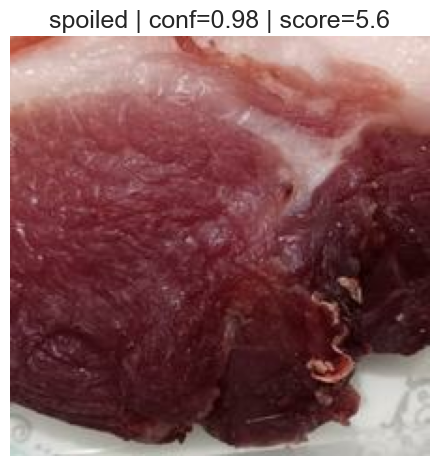

Best model based on macro F1-score: ResNet50 on exp2 (F1=0.4922, Accuracy=0.5754)
Cross-experiment shifts are expected because exp1 and exp2 can differ in capture distribution, so macro F1 is used as the primary comparison metric.


In [43]:
speed_records = []
for backbone_name in BACKBONES:
    for exp_name in SPLITS:
        model = trained_models[backbone_name][exp_name]
        test_df = test_frames[exp_name]
        preprocess_fn = preprocess_fns[backbone_name]
        mean_ms, std_ms = measure_inference_speed(model, test_df, preprocess_fn, n=50)
        speed_records.append(
            {
                "backbone": backbone_name,
                "experiment": exp_name,
                "mean_ms_per_image": mean_ms,
                "std_ms_per_image": std_ms,
            }
        )

speed_df = pd.DataFrame(speed_records).sort_values(["backbone", "experiment"]).reset_index(drop=True)
print("Inference speed table:")
display(speed_df)

size_table = metrics_df[["backbone", "experiment", "h5_mb", "tflite_mb"]].copy()
print("Model size table:")
display(size_table)

comparison_table = (
    avg_by_backbone.merge(
        speed_df.groupby("backbone", as_index=False)[["mean_ms_per_image", "std_ms_per_image"]].mean(),
        on="backbone",
        how="left",
    )
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
print("Final backbone comparison table:")
display(comparison_table)

best_run_backbone = best_run["backbone"]
best_run_exp = best_run["experiment"]
best_model = trained_models[best_run_backbone][best_run_exp]
best_preprocess_fn = preprocess_fns[best_run_backbone]
best_test_df = test_frames[best_run_exp]
example_row = best_test_df.sample(1, random_state=SEED).iloc[0]
example_image = preprocess_single_image(example_row["roi_path"], best_preprocess_fn)
example_probs = best_model(tf.expand_dims(example_image, axis=0), training=False).numpy()[0]
pred_label, confidence, freshness, recommendation = freshness_score(example_probs, label_vocab)

example_prediction = pd.DataFrame([
    {
        "image_path": example_row["roi_path"],
        "predicted_class": pred_label,
        "confidence": confidence,
        "freshness_score": freshness,
        "recommendation": recommendation,
    }
])
print("Example single-image prediction:")
display(example_prediction)

raw_example = tf.io.read_file(example_row["roi_path"])
raw_example_img = tf.io.decode_image(raw_example, channels=3, expand_animations=False)
plt.figure(figsize=(5, 5))
plt.imshow(raw_example_img.numpy())
plt.axis("off")
plt.title(f"{pred_label} | conf={confidence:.2f} | score={freshness:.1f}")
plt.tight_layout()
plt.show()

print(
    f"Best model based on macro F1-score: {best_run_backbone} on {best_run_exp} "
    f"(F1={best_run['f1_macro']:.4f}, Accuracy={best_run['accuracy']:.4f})"
)
print(
    "Cross-experiment shifts are expected because exp1 and exp2 can differ in capture distribution, "
    "so macro F1 is used as the primary comparison metric."
)

## Upload Image for ROI Inference

Run this cell after the training/evaluation cells above. Uploading an image automatically applies the same centered ROI crop logic and returns `predicted_class`, `confidence`, `freshness_score`, and `recommendation`.

In [51]:
try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("ipywidgets is required for the upload cell. Install it with `pip install ipywidgets`.") from exc

UPLOAD_DIR = Path("inference_uploads")
UPLOAD_DIR.mkdir(exist_ok=True)


def center_square_crop_tensor(image, crop_ratio=0.7):
    image = tf.convert_to_tensor(image)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    side = tf.cast(
        tf.maximum(
            1,
            tf.round(tf.cast(tf.minimum(h, w), tf.float32) * tf.cast(crop_ratio, tf.float32)),
        ),
        tf.int32,
    )
    top = (h - side) // 2
    left = (w - side) // 2
    return tf.image.crop_to_bounding_box(image, top, left, side, side)


def save_uploaded_file(upload_entry):
    name = Path(upload_entry["name"]).name
    file_path = UPLOAD_DIR / name
    file_path.write_bytes(upload_entry["content"])
    return file_path


def preprocess_uploaded_roi(roi_tensor, preprocess_fn):
    roi_resized = tf.image.resize(roi_tensor, IMG_SIZE, method="bilinear")
    roi_float = tf.image.convert_image_dtype(roi_resized, tf.float32)
    roi_float = tf.clip_by_value(roi_float, 0.0, 1.0)
    return preprocess_fn(roi_float * 255.0), roi_resized


def predict_uploaded_image(file_path, model, preprocess_fn, label_names):
    raw_bytes = tf.io.read_file(str(file_path))
    original = tf.io.decode_image(raw_bytes, channels=3, expand_animations=False)
    original.set_shape([None, None, 3])

    roi = center_square_crop_tensor(original, crop_ratio=0.7)
    preprocessed_roi, roi_resized = preprocess_uploaded_roi(roi, preprocess_fn)
    probs = model(tf.expand_dims(preprocessed_roi, axis=0), training=False).numpy()[0]
    pred_label, confidence, freshness, recommendation = freshness_score(probs, label_names)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original.numpy())
    axes[0].set_title("Uploaded image")
    axes[0].axis("off")
    axes[1].imshow(tf.cast(tf.clip_by_value(roi_resized, 0.0, 255.0), tf.uint8).numpy())
    axes[1].set_title("Automatic ROI")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    result_df = pd.DataFrame([
        {
            "predicted_class": pred_label,
            "confidence": round(confidence, 4),
            "freshness_score": round(freshness, 2),
            "recommendation": recommendation,
        }
    ])
    display(result_df)
    return result_df


def _extract_single_upload(change_value):
    if isinstance(change_value, dict):
        entries = list(change_value.values())
    else:
        entries = list(change_value)
    if not entries:
        return None
    return entries[0]


def on_upload_change(change):
    if not change.get("new"):
        return
    upload_entry = _extract_single_upload(change["new"])
    if upload_entry is None:
        return
    output.clear_output(wait=True)
    with output:
        if "best_model" not in globals() or "best_preprocess_fn" not in globals():
            print("Run the training/evaluation cells first so `best_model` and `best_preprocess_fn` are available.")
            return
        file_path = save_uploaded_file(upload_entry)
        print(f"Processing: {file_path.name}")
        predict_uploaded_image(file_path, best_model, best_preprocess_fn, label_vocab)


upload_widget = widgets.FileUpload(accept="image/*", multiple=False, description="Upload Image")
output = widgets.Output()
upload_widget.observe(on_upload_change, names="value")
display(widgets.VBox([upload_widget, output]))


ImportError: ipywidgets is required for the upload cell. Install it with `pip install ipywidgets`.